## Структура ноутбука

1. Проверка GPU и RAPIDS runtime.
2. Загрузка датасета и подготовка выборок.
3. Описание протокола оценки и набора baseline-моделей.
4. Единый конфигурационный блок с настройками всех моделей.
5. Отдельное обучение логистической регрессии.
6. Отдельное обучение MultinomialNB.
7. Отдельное обучение RandomForestClassifier.
8. Сводное сравнение всех кандидатов.
9. Анализ ошибок лучшей модели.
10. Сохранение артефактов и итоговый вывод.


In [1]:
import ctypes
import json
import os
import pickle
import re
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from datasets import load_dataset, load_from_disk
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import ParameterGrid, StratifiedGroupKFold, train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path(r"/home/sukuna/Projects/RNN")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
REPORTS_DIR = ARTIFACTS_DIR / "reports"
SNAPSHOT_DIR = RAW_DATA_DIR / "banking77_snapshot"
LABEL_MAPPING_PATH = RAW_DATA_DIR / "label_mapping.json"

DATASET_NAME = "PolyAI/banking77"
DATASET_REVISION = "refs/pr/6"
RANDOM_STATE = 42
VAL_SIZE = 0.2
WHITESPACE_RE = re.compile(r"\s+")
CUDA_RELEASE_RE = re.compile(r"release\s+(\d+)\.(\d+)", re.IGNORECASE)
DRIVER_RELEASE_RE = re.compile(r"\b(\d+)\.(\d+)\.(\d+)\b")


/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Проверка RAPIDS и GPU

Поскольку классические модели в этом ноутбуке обучаются через `cuDF/cuML`,
перед запуском важно убедиться, что доступен совместимый CUDA runtime и что GPU
действительно виден из Python-окружения.

In [2]:
def run_command(command: list[str]) -> str:
    try:
        completed = subprocess.run(command, check=False, capture_output=True, text=True)
    except FileNotFoundError:
        return ""
    return completed.stdout.strip() if completed.returncode == 0 else ""


def decode_cuda_version(raw_version: int | None) -> str | None:
    if raw_version in (None, 0):
        return None
    major = raw_version // 1000
    minor = (raw_version % 1000) // 10
    return f"{major}.{minor}"


def find_host_driver_library() -> str | None:
    candidates = [
        Path("/run/host/usr/lib/libcuda.so.1"),
        Path("/run/host/usr/lib/libcuda.so"),
        Path("/usr/lib/x86_64-linux-gnu/libcuda.so.1"),
        Path("/usr/lib64/libcuda.so.1"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return None


def preload_nvidia_driver_libraries() -> dict:
    driver_library_path = find_host_driver_library()
    management_library_path = None
    preload_error = None

    if driver_library_path is None:
        return {
            "driver_library_path": None,
            "management_library_path": None,
            "preload_error": "libcuda.so.1 не найден в ожидаемых путях.",
        }

    try:
        ctypes.CDLL(driver_library_path, mode=ctypes.RTLD_GLOBAL)
        management_candidate = Path("/run/host/usr/lib/libnvidia-ml.so.1")
        if management_candidate.exists():
            ctypes.CDLL(str(management_candidate), mode=ctypes.RTLD_GLOBAL)
            management_library_path = str(management_candidate)
    except OSError as exc:
        preload_error = f"{type(exc).__name__}: {exc}"

    return {
        "driver_library_path": driver_library_path,
        "management_library_path": management_library_path,
        "preload_error": preload_error,
    }


def detect_cuda_runtime() -> dict:
    nvcc_candidates = [
        Path(os.environ.get("CUDA_PATH", "")) / "bin" / "nvcc",
        Path("/opt/cuda/bin/nvcc"),
        Path("/usr/local/cuda/bin/nvcc"),
    ]
    nvcc_path = next((candidate for candidate in nvcc_candidates if candidate.exists()), None)

    cuda_major = None
    cuda_minor = None
    if nvcc_path is not None:
        nvcc_output = run_command([str(nvcc_path), "--version"])
        match = CUDA_RELEASE_RE.search(nvcc_output)
        if match:
            cuda_major = int(match.group(1))
            cuda_minor = int(match.group(2))

    driver_major = None
    driver_version_path = Path("/proc/driver/nvidia/version")
    driver_version_text = None
    if driver_version_path.exists():
        driver_version_text = driver_version_path.read_text(encoding="utf-8")
        match = DRIVER_RELEASE_RE.search(driver_version_text)
        if match:
            driver_major = int(match.group(1))

    has_nvidia_devices = any(Path(path).exists() for path in ("/dev/nvidiactl", "/dev/nvidia0"))
    compatible = False
    package_suffix = None
    if cuda_major is not None and driver_major is not None and has_nvidia_devices:
        if cuda_major >= 13 and driver_major >= 580:
            compatible = True
            package_suffix = "cu13"
        elif cuda_major >= 12 and driver_major >= 525:
            compatible = True
            package_suffix = "cu12"

    preload_info = preload_nvidia_driver_libraries()

    return {
        "compatible": compatible,
        "package_suffix": package_suffix,
        "cuda_major": cuda_major,
        "cuda_minor": cuda_minor,
        "driver_major": driver_major,
        "driver_version_text": driver_version_text,
        "nvcc_path": str(nvcc_path) if nvcc_path is not None else None,
        "has_nvidia_devices": has_nvidia_devices,
        "nvidia_smi": run_command(["nvidia-smi"]),
        **preload_info,
    }


def collect_cupy_runtime_info(cp) -> dict:
    info = {
        "cupy_version": getattr(cp, "__version__", None),
        "driver_version_raw": None,
        "driver_version": None,
        "runtime_version_raw": None,
        "runtime_version": None,
        "gpu_count": None,
        "cuda_runtime_error": None,
    }

    try:
        driver_raw = int(cp.cuda.runtime.driverGetVersion())
        info["driver_version_raw"] = driver_raw
        info["driver_version"] = decode_cuda_version(driver_raw)
    except Exception as exc:
        info["cuda_runtime_error"] = f"{type(exc).__name__}: {exc}"

    try:
        runtime_raw = int(cp.cuda.runtime.runtimeGetVersion())
        info["runtime_version_raw"] = runtime_raw
        info["runtime_version"] = decode_cuda_version(runtime_raw)
    except Exception as exc:
        if info["cuda_runtime_error"] is None:
            info["cuda_runtime_error"] = f"{type(exc).__name__}: {exc}"

    try:
        info["gpu_count"] = int(cp.cuda.runtime.getDeviceCount())
    except Exception as exc:
        info["cuda_runtime_error"] = f"{type(exc).__name__}: {exc}"

    return info


def build_rapids_runtime_error(runtime: dict, cupy_info: dict | None = None) -> str:
    lines_out = [
        "RAPIDS/CUDA runtime недоступен для выполнения этого ноутбука.",
        "",
        "Диагностика окружения:",
        f"- CUDA toolkit по nvcc: {runtime['cuda_major']}.{runtime['cuda_minor']}" if runtime["cuda_major"] is not None else "- CUDA toolkit по nvcc: не определён",
        f"- kernel-драйвер NVIDIA: {runtime['driver_major']}" if runtime["driver_major"] is not None else "- kernel-драйвер NVIDIA: не определён",
        f"- устройства /dev/nvidia*: {'да' if runtime['has_nvidia_devices'] else 'нет'}",
        f"- ожидаемый пакет RAPIDS: {runtime['package_suffix']}" if runtime["package_suffix"] else "- ожидаемый пакет RAPIDS: не определён",
        f"- nvidia-smi: {'доступен' if runtime['nvidia_smi'] else 'недоступен'}",
        f"- путь к libcuda.so.1: {runtime['driver_library_path'] or 'не найден'}",
        f"- путь к libnvidia-ml.so.1: {runtime['management_library_path'] or 'не найден'}",
    ]
    if runtime.get("preload_error"):
        lines_out.extend(["- ошибка предзагрузки драйвера: " + str(runtime["preload_error"])])

    if cupy_info is not None:
        lines_out.extend(
            [
                f"- версия CuPy: {cupy_info['cupy_version']}",
                f"- CUDA runtime внутри Python: {cupy_info['runtime_version'] or cupy_info['runtime_version_raw'] or 'не определён'}",
                f"- CUDA driver API внутри Python: {cupy_info['driver_version'] or cupy_info['driver_version_raw'] or 'не определён'}",
                f"- число GPU по CuPy: {cupy_info['gpu_count'] if cupy_info['gpu_count'] is not None else 'не определено'}",
            ]
        )
        if cupy_info["cuda_runtime_error"]:
            lines_out.extend([
                "",
                "Низкоуровневая ошибка CUDA:",
                f"- {cupy_info['cuda_runtime_error']}",
            ])
        if cupy_info.get("driver_version_raw") == 0:
            lines_out.extend([
                "",
                "Дополнительное наблюдение:",
                "- CuPy вернул `driverGetVersion() = 0`, это часто означает, что пользовательская библиотека драйвера CUDA недоступна или несовместима с текущим окружением.",
            ])

    lines_out.extend([
        "",
        "Что это обычно означает:",
        "- драйвер NVIDIA на хосте старее, чем установленный CUDA runtime в окружении; или",
        "- в контейнер/удалённую среду проброшены устройства `/dev/nvidia*`, но не проброшены корректные пользовательские библиотеки драйвера; или",
        "- установлена ветка RAPIDS не под ту версию CUDA.",
        "",
        "Что проверить дальше:",
        "- если ваша машина поддерживает только CUDA 12, пересоздайте `.venv-gpu` с пакетами `cudf-cu12`, `cuml-cu12`, `cupy-cuda12x`;",
        "- если вы рассчитываете на CUDA 13, проверьте доступность `nvidia-smi` и корректный проброс `libcuda.so` в текущее окружение;",
        "- после исправления окружения снова запустите ячейку проверки RAPIDS.",
    ])
    return "\n".join(lines_out)


def assert_rapids_runtime() -> dict:
    runtime = detect_cuda_runtime()
    if not runtime["compatible"]:
        raise RuntimeError(build_rapids_runtime_error(runtime))

    preload_info = preload_nvidia_driver_libraries()
    runtime.update(preload_info)

    import cupy as cp
    import cudf
    from cuml.feature_extraction.text import TfidfVectorizer
    from cuml.linear_model import LogisticRegression

    cupy_info = collect_cupy_runtime_info(cp)
    if cupy_info["gpu_count"] is None or cupy_info["gpu_count"] < 1:
        raise RuntimeError(build_rapids_runtime_error(runtime, cupy_info))

    try:
        texts = cudf.Series([
            "card payment reversed",
            "cash withdrawal failed",
            "cash withdrawal cashpoint",
            "password reset account access",
        ])
        labels = cp.asarray([0, 1, 1, 2], dtype=cp.int32)

        vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
        features = vectorizer.fit_transform(texts)
        model = LogisticRegression(max_iter=200)
        model.fit(features, labels)
        preds = model.predict(features)
    except Exception as exc:
        cupy_info["cuda_runtime_error"] = f"{type(exc).__name__}: {exc}"
        raise RuntimeError(build_rapids_runtime_error(runtime, cupy_info)) from None

    return {
        **runtime,
        **cupy_info,
        "smoke_features_shape": tuple(int(x) for x in features.shape),
        "smoke_predictions_shape": tuple(int(x) for x in preds.shape),
    }


In [3]:
runtime = assert_rapids_runtime()
display(Markdown("### Результат проверки окружения"))
pd.DataFrame([runtime])

### Результат проверки окружения

,compatible,package_suffix,cuda_major,cuda_minor,driver_major,driver_version_text,nvcc_path,has_nvidia_devices,nvidia_smi,driver_library_path,management_library_path,preload_error,cupy_version,driver_version_raw,driver_version,runtime_version_raw,runtime_version,gpu_count,cuda_runtime_error,smoke_features_shape,smoke_predictions_shape
0,True,cu13,13,1,590,NVRM version: NVIDIA UNIX Open Kernel Module for x86_64 590.48.01 Release Build (root@) \nGCC version: gcc version 15.2.1 20260209 (GCC) \n,/opt/cuda/bin/nvcc,True,,/run/host/usr/lib/libcuda.so.1,/run/host/usr/lib/libnvidia-ml.so.1,None,14.0.1,13010,13.1,13000,13.0,1,None,"(4, 19)","(4,)"


## Загрузка данных и подготовка выборок

Для воспроизводимости используем тот же snapshot `Banking77`, который был подготовлен на этапе EDA.
Если snapshot уже есть локально, ноутбук использует его; если нет — скачивает датасет и сохраняет на диск.

В ноутбуке используется фиксированное `train / val / test`-разбиение:
- `train` — обучение моделей;
- `val` — подбор конфигураций и сравнение кандидатов;
- `test` — только финальная оценка уже выбранных моделей.

Дополнительно ниже проводится cross-validation и GPU-backed grid search на `train`,
чтобы получить более устойчивую оценку гиперпараметров без использования `test` на этапе подбора.


In [4]:
def load_banking77_snapshot(force_refresh: bool = False):
    RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)

    if SNAPSHOT_DIR.exists() and not force_refresh:
        return load_from_disk(str(SNAPSHOT_DIR))

    dataset = load_dataset(DATASET_NAME, revision=DATASET_REVISION, cache_dir=str(RAW_DATA_DIR / "hf_cache"))
    dataset.save_to_disk(str(SNAPSHOT_DIR))
    label_mapping = {i: label for i, label in enumerate(dataset["train"].features["label"].names)}
    LABEL_MAPPING_PATH.write_text(json.dumps(label_mapping, indent=2, ensure_ascii=False), encoding="utf-8")
    return dataset


def normalize_text(text: str) -> str:
    text = text if isinstance(text, str) else ""
    text = text.strip().lower()
    text = WHITESPACE_RE.sub(" ", text)
    return text


def split_to_frame(dataset, split_name: str) -> pd.DataFrame:
    label_names = list(dataset["train"].features["label"].names)
    frame = dataset[split_name].to_pandas()[["text", "label"]].copy()
    frame["label_name"] = frame["label"].map(lambda idx: label_names[int(idx)])
    frame["text_normalized"] = frame["text"].map(normalize_text)
    frame["char_length"] = frame["text_normalized"].str.len()
    frame["word_length"] = frame["text_normalized"].str.split().str.len()
    return frame


def deduplicate_exact_texts(frame: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    deduplicated = frame.drop_duplicates(subset=["text_normalized", "label"], keep="first").reset_index(drop=True)
    removed_count = int(len(frame) - len(deduplicated))
    return deduplicated, removed_count


def remove_train_test_text_overlap(train_frame: pd.DataFrame, test_frame: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    test_texts = set(test_frame["text_normalized"].tolist())
    overlap_mask = train_frame["text_normalized"].isin(test_texts)
    cleaned_train = train_frame.loc[~overlap_mask].reset_index(drop=True)
    removed_count = int(overlap_mask.sum())
    return cleaned_train, removed_count


def build_experiment_splits(dataset):
    official_train_raw = split_to_frame(dataset, "train")
    official_test_raw = split_to_frame(dataset, "test")

    official_train_dedup, removed_train_duplicates = deduplicate_exact_texts(official_train_raw)
    official_test_dedup, removed_test_duplicates = deduplicate_exact_texts(official_test_raw)
    official_train_clean, removed_train_test_overlap = remove_train_test_text_overlap(
        official_train_dedup,
        official_test_dedup,
    )

    train_df, val_df = train_test_split(
        official_train_clean,
        test_size=VAL_SIZE,
        random_state=RANDOM_STATE,
        stratify=official_train_clean["label"],
    )

    split_frames = {
        "official_train": official_train_clean.reset_index(drop=True),
        "official_test": official_test_dedup.reset_index(drop=True),
        "train": train_df.reset_index(drop=True),
        "val": val_df.reset_index(drop=True),
        "test": official_test_dedup.reset_index(drop=True),
    }
    raw_split_frames = {
        "official_train_raw": official_train_raw.reset_index(drop=True),
        "official_test_raw": official_test_raw.reset_index(drop=True),
    }
    cleaning_report_df = pd.DataFrame(
        [
            {
                "Шаг очистки": "Удаление точных дубликатов в official_train",
                "Удалено строк": removed_train_duplicates,
            },
            {
                "Шаг очистки": "Удаление точных дубликатов в official_test",
                "Удалено строк": removed_test_duplicates,
            },
            {
                "Шаг очистки": "Удаление пересечений official_train с official_test",
                "Удалено строк": removed_train_test_overlap,
            },
        ]
    )
    return split_frames, raw_split_frames, cleaning_report_df


def summarize_splits(split_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for split_name, frame in split_frames.items():
        rows.append(
            {
                "split": split_name,
                "rows": int(len(frame)),
                "unique_labels": int(frame["label"].nunique()),
                "missing_texts": int(frame["text"].isna().sum()),
                "missing_labels": int(frame["label"].isna().sum()),
                "mean_char_length": round(float(frame["char_length"].mean()), 2),
                "mean_word_length": round(float(frame["word_length"].mean()), 2),
            }
        )
    return pd.DataFrame(rows).sort_values("split").reset_index(drop=True)


def load_label_names(dataset) -> list[str]:
    label_mapping = {i: label for i, label in enumerate(dataset["train"].features["label"].names)}
    LABEL_MAPPING_PATH.write_text(json.dumps(label_mapping, indent=2, ensure_ascii=False), encoding="utf-8")
    return [label_mapping[i] for i in sorted(label_mapping)]


def build_within_split_duplicate_report(split_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for split_name, frame in split_frames.items():
        duplicate_mask = frame["text_normalized"].duplicated(keep=False)
        duplicate_rows = frame.loc[duplicate_mask].copy()
        rows.append(
            {
                "split": split_name,
                "rows": int(len(frame)),
                "unique_normalized_texts": int(frame["text_normalized"].nunique()),
                "duplicate_rows": int(duplicate_mask.sum()),
                "duplicate_unique_texts": int(duplicate_rows["text_normalized"].nunique()) if not duplicate_rows.empty else 0,
            }
        )
    return pd.DataFrame(rows).sort_values("split").reset_index(drop=True)


def build_between_split_overlap_report(split_frames: dict[str, pd.DataFrame], split_names: list[str]) -> pd.DataFrame:
    rows = []
    for idx, split_a in enumerate(split_names):
        texts_a = set(split_frames[split_a]["text_normalized"].tolist())
        for split_b in split_names[idx + 1:]:
            texts_b = set(split_frames[split_b]["text_normalized"].tolist())
            rows.append(
                {
                    "split_a": split_a,
                    "split_b": split_b,
                    "shared_normalized_texts": int(len(texts_a & texts_b)),
                }
            )
    return pd.DataFrame(rows).sort_values(["shared_normalized_texts", "split_a", "split_b"], ascending=[False, True, True]).reset_index(drop=True)


In [5]:
dataset = load_banking77_snapshot()
label_names = load_label_names(dataset)
official_counts = {split_name: len(split) for split_name, split in dataset.items()}
split_frames, raw_split_frames, cleaning_report_df = build_experiment_splits(dataset)
raw_split_summary = summarize_splits(raw_split_frames)
split_summary = summarize_splits(split_frames)
raw_within_split_duplicates_df = build_within_split_duplicate_report(raw_split_frames)
within_split_duplicates_df = build_within_split_duplicate_report(split_frames)
raw_overlap_df = build_between_split_overlap_report(raw_split_frames, ["official_train_raw", "official_test_raw"])
overlap_split_names = [split_name for split_name in ["official_train", "official_test", "train", "val", "test"] if split_name in split_frames]
between_split_overlap_df = build_between_split_overlap_report(split_frames, overlap_split_names)

assert official_counts == {"train": 10003, "test": 3080}
assert len(label_names) == 77

display(Markdown("### Контроль размеров исходного датасета"))
print("Official split'ы из исходного snapshot:", official_counts)
print("Количество классов:", len(label_names))
display(raw_split_summary)

display(Markdown("### Дубликаты и пересечения до очистки"))
display(raw_within_split_duplicates_df)
display(raw_overlap_df)

display(Markdown("### Что было удалено на этапе очистки"))
display(cleaning_report_df)

display(Markdown("### Рабочие split'ы после очистки"))
display(split_summary)

display(Markdown("### Дубликаты внутри рабочих split'ов"))
display(within_split_duplicates_df)

display(Markdown("### Пересечения по нормализованным текстам между рабочими split'ами"))
between_split_overlap_df


### Контроль размеров исходного датасета

Official split'ы из исходного snapshot: {'train': 10003, 'test': 3080}
Количество классов: 77


,split,rows,unique_labels,missing_texts,missing_labels,mean_char_length,mean_word_length
0,official_test_raw,3080,77,0,0,54.19,10.95
1,official_train_raw,10003,77,0,0,59.41,11.95


### Дубликаты и пересечения до очистки

,split,rows,unique_normalized_texts,duplicate_rows,duplicate_unique_texts
0,official_test_raw,3080,3079,2,1
1,official_train_raw,10003,9999,8,4


...

,split,rows,unique_labels,missing_texts,missing_labels,mean_char_length,mean_word_length
0,official_test,3079,77,0,0,54.20,10.95
1,official_train,9992,77,0,0,59.42,11.95
2,test,3079,77,0,0,54.20,10.95
3,train,7993,77,0,0,59.60,11.98
4,val,1999,77,0,0,58.71,11.84


### Дубликаты внутри рабочих split'ов

,split,rows,unique_normalized_texts,duplicate_rows,duplicate_unique_texts
0,official_test,3079,3079,0,0
1,official_train,9992,9992,0,0
2,test,3079,3079,0,0
3,train,7993,7993,0,0
4,val,1999,1999,0,0


### Пересечения по нормализованным текстам между рабочими split'ами

,split_a,split_b,shared_normalized_texts
0,official_train,train,7993
1,official_test,test,3079
2,official_train,val,1999
3,official_test,train,0
4,official_test,val,0
5,official_train,official_test,0
6,official_train,test,0
7,train,test,0
8,train,val,0
9,val,test,0


## Протокол эксперимента и метрики

В ноутбуке сравниваются три семейства классических моделей:

- `Logistic Regression` — сильный линейный baseline для текстовой классификации;
- `MultinomialNB` — простой и быстрый вероятностный baseline;
- `RandomForestClassifier` — нелинейная модель, для которой используем плотное представление с ограниченным числом признаков.

В качестве текстовых признаков используется TF-IDF. Для оценки качества считаются:

- `accuracy`;
- `precision_macro`, `recall_macro`, `f1_macro`;
- `precision_weighted`, `recall_weighted`, `f1_weighted`.

В текущей версии ноутбука выбор лучшей конфигурации внутри семейства и выбор `best_overall`
выполняются по `val macro-F1`, а `val accuracy` используется как дополнительный критерий при равенстве.
Метрики на `test` используются только для финальной оценки уже выбранных моделей.


In [6]:
import cupy as cp
import cudf
from cuml.ensemble import RandomForestClassifier
from cuml.feature_extraction.text import TfidfVectorizer
from cuml.linear_model import LogisticRegression
from cuml.naive_bayes import MultinomialNB


def to_numpy(vector) -> np.ndarray:
    if hasattr(vector, "to_numpy"):
        return np.asarray(vector.to_numpy()).reshape(-1)
    if hasattr(vector, "get"):
        return np.asarray(vector.get()).reshape(-1)
    return np.asarray(vector).reshape(-1)


def split_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(macro_precision),
        "recall_macro": float(macro_recall),
        "f1_macro": float(macro_f1),
        "precision_weighted": float(weighted_precision),
        "recall_weighted": float(weighted_recall),
        "f1_weighted": float(weighted_f1),
    }


def format_metric(value: float) -> str:
    return f"{value:.4f}"


def build_metrics_rows(model_name: str, candidate_name: str, metrics_by_split: dict[str, dict]) -> list[dict]:
    rows = []
    for split_name, metrics in metrics_by_split.items():
        rows.append(
            {
                "split": split_name,
                "model": model_name,
                "candidate": candidate_name,
                **{key: round(float(value), 5) for key, value in metrics.items()},
            }
        )
    return rows


def save_pickle(bundle: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as handle:
        pickle.dump(bundle, handle)


def save_confusion_matrix_figure(y_true: np.ndarray, y_pred: np.ndarray, label_names: list[str], output_path: Path) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))), normalize="true")
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, cmap="Blues", cbar=True)
    plt.title("Нормированная матрица ошибок лучшей модели")
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


def per_class_metrics_frame(y_true: np.ndarray, y_pred: np.ndarray, label_names: list[str]) -> pd.DataFrame:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(label_names))),
        average=None,
        zero_division=0,
    )
    return (
        pd.DataFrame(
            {
                "label": list(range(len(label_names))),
                "label_name": label_names,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "support": support,
            }
        )
        .sort_values(["f1", "support"], ascending=[True, False])
        .reset_index(drop=True)
    )


def family_candidates_table(candidates: list[dict]) -> pd.DataFrame:
    rows = []
    for item in candidates:
        rows.append(
            {
                "candidate_name": item["candidate_name"],
                "представление": item["representation_label"],
                "ngram_range": str(item["vectorizer_kwargs"]["ngram_range"]),
                "max_features": item["vectorizer_kwargs"]["max_features"],
                "min_df": item["vectorizer_kwargs"].get("min_df", 1),
                "параметры_модели": item["model_description"],
            }
        )
    return pd.DataFrame(rows)


TRAINING_LOG_RENAME = {
    "family_label": "Семейство модели",
    "candidate_name": "Кандидат",
    "representation": "Представление",
    "matrix_shape": "Размер матрицы train",
    "feature_count": "Число признаков",
    "fit_sec": "Время обучения, сек",
    "predict_train_sec": "Время train-предсказания, сек",
    "predict_val_sec": "Время val-предсказания, сек",
    "predict_test_sec": "Время test-предсказания, сек",
    "train_accuracy": "Train accuracy",
    "train_f1_macro": "Train macro-F1",
    "val_accuracy": "Val accuracy",
    "val_f1_macro": "Val macro-F1",
    "test_accuracy": "Test accuracy",
    "test_f1_macro": "Test macro-F1",
    "overfit_gap_f1": "Разница train-val по macro-F1",
    "model_description": "Параметры модели",
    "vectorizer_description": "Параметры TF-IDF",
    "is_best_family": "Лучшая в семействе",
}

BEST_FAMILY_RENAME = {
    "family_label": "Семейство модели",
    "candidate_name": "Лучший кандидат",
    "val_macro_f1": "Val macro-F1",
    "test_macro_f1": "Test macro-F1",
    "test_accuracy": "Test accuracy",
    "fit_sec": "Время обучения, сек",
    "representation": "Представление",
}

PER_CLASS_RENAME = {
    "label": "Индекс класса",
    "label_name": "Класс",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "support": "Число примеров",
}

CONFUSION_PAIRS_RENAME = {
    "label_name": "Истинный класс",
    "prediction_name": "Предсказанный класс",
    "count": "Количество ошибок",
}

ERROR_EXAMPLES_RENAME = {
    "text": "Текст обращения",
    "label_name": "Истинный класс",
    "prediction_name": "Предсказанный класс",
}


def russian_training_log(df: pd.DataFrame) -> pd.DataFrame:
    ordered_columns = [
        "family_label",
        "candidate_name",
        "representation",
        "matrix_shape",
        "feature_count",
        "fit_sec",
        "predict_val_sec",
        "predict_test_sec",
        "train_f1_macro",
        "val_f1_macro",
        "test_f1_macro",
        "train_accuracy",
        "val_accuracy",
        "test_accuracy",
        "overfit_gap_f1",
        "is_best_family",
        "model_description",
        "vectorizer_description",
    ]
    available_columns = [column for column in ordered_columns if column in df.columns]
    return df.loc[:, available_columns].rename(columns=TRAINING_LOG_RENAME)


def russian_best_family_table(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=BEST_FAMILY_RENAME)


def russian_per_class_table(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=PER_CLASS_RENAME)


def russian_confusion_pairs_table(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=CONFUSION_PAIRS_RENAME)


def russian_error_examples_table(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=ERROR_EXAMPLES_RENAME)


def run_model_family(
    family_name: str,
    family_label: str,
    candidates: list[dict],
    split_frames: dict[str, pd.DataFrame],
    label_names: list[str],
) -> dict:
    train_df = split_frames["train"].copy()
    val_df = split_frames["val"].copy()
    test_df = split_frames["test"].copy()

    train_texts = cudf.Series(train_df["text_normalized"].tolist())
    val_texts = cudf.Series(val_df["text_normalized"].tolist())
    test_texts = cudf.Series(test_df["text_normalized"].tolist())

    y_train_gpu = cp.asarray(train_df["label"].to_numpy(dtype=np.int32))
    y_train = train_df["label"].to_numpy(dtype=np.int32)
    y_val = val_df["label"].to_numpy(dtype=np.int32)
    y_test = test_df["label"].to_numpy(dtype=np.int32)

    log_rows = []
    metrics_rows = []
    candidate_results = []

    print()
    print(f"===== Семейство моделей: {family_label} =====")
    print(f"Количество кандидатов: {len(candidates)}")

    for idx, candidate in enumerate(candidates, start=1):
        print("-" * 100)
        print(f"[{family_label}] Кандидат {idx}/{len(candidates)}: {candidate['candidate_name']}")
        print(f"TF-IDF параметры: {candidate['vectorizer_kwargs']}")
        print(f"Тип представления: {candidate['representation_label']}")
        print(f"Параметры модели: {candidate['model_description']}")

        vectorizer = TfidfVectorizer(**candidate["vectorizer_kwargs"])
        model = candidate["model_factory"]()

        train_features = vectorizer.fit_transform(train_texts)
        val_features = vectorizer.transform(val_texts)
        test_features = vectorizer.transform(test_texts)

        matrix_shape_before_dense = tuple(int(x) for x in train_features.shape)
        feature_count = int(train_features.shape[1])

        if candidate["dense"]:
            train_features = train_features.astype(np.float32).toarray()
            val_features = val_features.astype(np.float32).toarray()
            test_features = test_features.astype(np.float32).toarray()
            matrix_shape_for_log = tuple(int(x) for x in train_features.shape)
        else:
            matrix_shape_for_log = matrix_shape_before_dense

        print(f"Размер train-матрицы признаков: {matrix_shape_for_log}")

        fit_start = time.perf_counter()
        model.fit(train_features, y_train_gpu)
        fit_sec = time.perf_counter() - fit_start

        train_pred_start = time.perf_counter()
        train_pred = to_numpy(model.predict(train_features))
        predict_train_sec = time.perf_counter() - train_pred_start

        val_pred_start = time.perf_counter()
        val_pred = to_numpy(model.predict(val_features))
        predict_val_sec = time.perf_counter() - val_pred_start

        test_pred_start = time.perf_counter()
        test_pred = to_numpy(model.predict(test_features))
        predict_test_sec = time.perf_counter() - test_pred_start

        metrics_train = split_metrics(y_train, train_pred)
        metrics_val = split_metrics(y_val, val_pred)
        metrics_test = split_metrics(y_test, test_pred)

        print(
            f"Время обучения: {fit_sec:.4f} c | "
            f"Предсказание train: {predict_train_sec:.4f} c | "
            f"val: {predict_val_sec:.4f} c | test: {predict_test_sec:.4f} c"
        )
        print(
            "Метрики train: "
            f"accuracy={format_metric(metrics_train['accuracy'])}, "
            f"macro-F1={format_metric(metrics_train['f1_macro'])}"
        )
        print(
            "Метрики val:   "
            f"accuracy={format_metric(metrics_val['accuracy'])}, "
            f"macro-F1={format_metric(metrics_val['f1_macro'])}"
        )
        print(
            "Метрики test:  "
            f"accuracy={format_metric(metrics_test['accuracy'])}, "
            f"macro-F1={format_metric(metrics_test['f1_macro'])}"
        )

        overfit_gap = metrics_train["f1_macro"] - metrics_val["f1_macro"]
        print(f"Разница train-val по macro-F1: {overfit_gap:.4f}")

        log_rows.append(
            {
                "family": family_name,
                "family_label": family_label,
                "candidate_name": candidate["candidate_name"],
                "representation": candidate["representation_label"],
                "matrix_shape": str(matrix_shape_for_log),
                "feature_count": feature_count,
                "fit_sec": round(fit_sec, 5),
                "predict_train_sec": round(predict_train_sec, 5),
                "predict_val_sec": round(predict_val_sec, 5),
                "predict_test_sec": round(predict_test_sec, 5),
                "train_accuracy": round(metrics_train["accuracy"], 5),
                "train_f1_macro": round(metrics_train["f1_macro"], 5),
                "val_accuracy": round(metrics_val["accuracy"], 5),
                "val_f1_macro": round(metrics_val["f1_macro"], 5),
                "test_accuracy": round(metrics_test["accuracy"], 5),
                "test_f1_macro": round(metrics_test["f1_macro"], 5),
                "overfit_gap_f1": round(overfit_gap, 5),
                "model_description": candidate["model_description"],
                "vectorizer_description": json.dumps(candidate["vectorizer_kwargs"], ensure_ascii=False),
                "is_best_family": False,
            }
        )

        metrics_rows.extend(
            build_metrics_rows(
                model_name=family_name,
                candidate_name=candidate["candidate_name"],
                metrics_by_split={
                    "train": metrics_train,
                    "val": metrics_val,
                    "test": metrics_test,
                },
            )
        )

        candidate_results.append(
            {
                "family": family_name,
                "family_label": family_label,
                "candidate_name": candidate["candidate_name"],
                "representation": candidate["representation_label"],
                "vectorizer_kwargs": candidate["vectorizer_kwargs"],
                "model_description": candidate["model_description"],
                "vectorizer": vectorizer,
                "model": model,
                "train_pred": train_pred,
                "val_pred": val_pred,
                "test_pred": test_pred,
                "metrics": {
                    "train": metrics_train,
                    "val": metrics_val,
                    "test": metrics_test,
                },
                "fit_sec": fit_sec,
                "predict_train_sec": predict_train_sec,
                "predict_val_sec": predict_val_sec,
                "predict_test_sec": predict_test_sec,
                "feature_count": feature_count,
                "matrix_shape": matrix_shape_for_log,
            }
        )

    family_log_df = pd.DataFrame(log_rows).sort_values(["val_f1_macro", "val_accuracy", "test_f1_macro"], ascending=[False, False, False]).reset_index(drop=True)
    family_metrics_df = pd.DataFrame(metrics_rows)
    best_candidate_name = family_log_df.iloc[0]["candidate_name"]
    best_candidate = next(item for item in candidate_results if item["candidate_name"] == best_candidate_name)

    family_log_df["is_best_family"] = family_log_df["candidate_name"].eq(best_candidate_name)

    return {
        "family": family_name,
        "family_label": family_label,
        "log_df": family_log_df,
        "metrics_df": family_metrics_df,
        "candidate_results": candidate_results,
        "best_candidate": best_candidate,
    }


def build_predictions_frame(test_df: pd.DataFrame, y_pred: np.ndarray, label_names: list[str]) -> pd.DataFrame:
    frame = test_df[["text", "label", "label_name"]].copy().reset_index(drop=True)
    frame["prediction"] = y_pred.astype(int)
    frame["prediction_name"] = [label_names[int(x)] for x in y_pred]
    frame["is_correct"] = frame["label"].eq(frame["prediction"])
    return frame


def most_confused_pairs(predictions_df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    mistakes = predictions_df.loc[~predictions_df["is_correct"]].copy()
    if mistakes.empty:
        return pd.DataFrame(columns=["label_name", "prediction_name", "count"])
    return (
        mistakes.groupby(["label_name", "prediction_name"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


## Конфигурация моделей

Чтобы все семейства baseline-моделей были заданы в одном стиле,
настройки векторизации и гиперпараметры вынесены в единый конфигурационный блок.
Это упрощает сравнение моделей, делает ноутбук более аккуратным и позволяет
изменять параметры эксперимента в одном месте.


In [7]:
MODEL_CONFIGS = {
    "logistic_regression": {
        "family_name": "logistic_regression",
        "family_label": "Логистическая регрессия",
        "config_title": "логистической регрессии",
        "model_class_name": "LogisticRegression",
        "representation_label": "разреженное",
        "dense": False,
        "candidates": [
            {
                "candidate_name": "lr_tfidf_20k_bigrams_c1",
                "vectorizer_kwargs": {"ngram_range": (1, 2), "max_features": 20000, "min_df": 2},
                "model_params": {"C": 1.0, "max_iter": 500},
            },
            {
                "candidate_name": "lr_tfidf_40k_bigrams_c2",
                "vectorizer_kwargs": {"ngram_range": (1, 2), "max_features": 40000, "min_df": 2},
                "model_params": {"C": 2.0, "max_iter": 500},
            },
        ],
    },
    "multinomial_nb": {
        "family_name": "multinomial_nb",
        "family_label": "Мультиномиальный наивный Байес",
        "config_title": "мультиномиального наивного Байеса",
        "model_class_name": "MultinomialNB",
        "representation_label": "разреженное",
        "dense": False,
        "candidates": [
            {
                "candidate_name": "nb_tfidf_20k_bigrams_alpha05",
                "vectorizer_kwargs": {"ngram_range": (1, 2), "max_features": 20000, "min_df": 2},
                "model_params": {"alpha": 0.5},
            },
            {
                "candidate_name": "nb_tfidf_40k_bigrams_alpha10",
                "vectorizer_kwargs": {"ngram_range": (1, 2), "max_features": 40000, "min_df": 2},
                "model_params": {"alpha": 1.0},
            },
        ],
    },
    "random_forest": {
        "family_name": "random_forest",
        "family_label": "Случайный лес",
        "config_title": "случайного леса",
        "model_class_name": "RandomForestClassifier",
        "representation_label": "плотное",
        "dense": True,
        "candidates": [
            {
                "candidate_name": "rf_dense_tfidf_1024_unigrams",
                "vectorizer_kwargs": {"ngram_range": (1, 1), "max_features": 1024, "min_df": 2},
                "model_params": {"n_estimators": 400, "max_depth": 24, "random_state": RANDOM_STATE, "n_streams": 4},
            },
            {
                "candidate_name": "rf_dense_tfidf_2048_unigrams",
                "vectorizer_kwargs": {"ngram_range": (1, 1), "max_features": 2048, "min_df": 2},
                "model_params": {"n_estimators": 500, "max_depth": 28, "random_state": RANDOM_STATE, "n_streams": 4},
            },
        ],
    },
}


def format_model_description(model_class_name: str, model_params: dict) -> str:
    params_repr = ", ".join(f"{key}={value!r}" for key, value in model_params.items())
    return f"{model_class_name}({params_repr})"


def make_model_factory(family_key: str, model_params: dict):
    if family_key == "logistic_regression":
        return lambda params=model_params: LogisticRegression(**params)
    if family_key == "multinomial_nb":
        return lambda params=model_params: MultinomialNB(**params)
    if family_key == "random_forest":
        return lambda params=model_params: RandomForestClassifier(**params)
    raise ValueError(f"Неизвестное семейство моделей: {family_key}")


def build_candidate_from_parts(
    family_key: str,
    candidate_name: str,
    vectorizer_kwargs: dict,
    model_params: dict,
) -> dict:
    family_config = MODEL_CONFIGS[family_key]
    return {
        "candidate_name": candidate_name,
        "vectorizer_kwargs": vectorizer_kwargs,
        "model_factory": make_model_factory(family_key, model_params),
        "model_description": format_model_description(
            family_config["model_class_name"],
            model_params,
        ),
        "dense": family_config["dense"],
        "representation_label": family_config["representation_label"],
    }


def build_candidates_from_config(family_key: str) -> list[dict]:
    family_config = MODEL_CONFIGS[family_key]
    candidates = []
    for candidate_spec in family_config["candidates"]:
        candidates.append(
            build_candidate_from_parts(
                family_key=family_key,
                candidate_name=candidate_spec["candidate_name"],
                vectorizer_kwargs=candidate_spec["vectorizer_kwargs"],
                model_params=candidate_spec["model_params"],
            )
        )
    return candidates


model_config_summary_rows = []
for family_key, family_config in MODEL_CONFIGS.items():
    for candidate_spec in family_config["candidates"]:
        model_config_summary_rows.append(
            {
                "Семейство модели": family_config["family_label"],
                "Кандидат": candidate_spec["candidate_name"],
                "Представление": family_config["representation_label"],
                "TF-IDF": str(candidate_spec["vectorizer_kwargs"]),
                "Параметры модели": format_model_description(
                    family_config["model_class_name"],
                    candidate_spec["model_params"],
                ),
            }
        )


display(Markdown("### Сводный конфиг всех baseline-моделей"))
pd.DataFrame(model_config_summary_rows)


### Сводный конфиг всех baseline-моделей

,Семейство модели,Кандидат,Представление,TF-IDF,Параметры модели
0,Логистическая регрессия,lr_tfidf_20k_bigrams_c1,разреженное,"{'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2}","LogisticRegression(C=1.0, max_iter=500)"
1,Логистическая регрессия,lr_tfidf_40k_bigrams_c2,разреженное,"{'ngram_range': (1, 2), 'max_features': 40000, 'min_df': 2}","LogisticRegression(C=2.0, max_iter=500)"
2,Мультиномиальный наивный Байес,nb_tfidf_20k_bigrams_alpha05,разреженное,"{'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2}",MultinomialNB(alpha=0.5)
3,Мультиномиальный наивный Байес,nb_tfidf_40k_bigrams_alpha10,разреженное,"{'ngram_range': (1, 2), 'max_features': 40000, 'min_df': 2}",MultinomialNB(alpha=1.0)
4,Случайный лес,rf_dense_tfidf_1024_unigrams,плотное,"{'ngram_range': (1, 1), 'max_features': 1024, 'min_df': 2}","RandomForestClassifier(n_estimators=400, max_depth=24, random_state=42, n_streams=4)"
5,Случайный лес,rf_dense_tfidf_2048_unigrams,плотное,"{'ngram_range': (1, 1), 'max_features': 2048, 'min_df': 2}","RandomForestClassifier(n_estimators=500, max_depth=28, random_state=42, n_streams=4)"


## Cross-validation и GPU grid search

Ниже добавлены helper-функции для более устойчивой оценки моделей.
Cross-validation выполняется на `train` с использованием `StratifiedGroupKFold`,
где группировкой служит нормализованный текст. Это помогает не допускать утечки
одинаковых дубликатов между fold'ами и делает сравнение моделей более надёжным.

В установленной версии RAPIDS/cuML orchestration сеточного поиска не даёт отдельного native GPU `GridSearchCV`,
поэтому ниже используется GPU-backed поиск по сетке: перебор параметров идёт в Python,
а каждое обучение и каждое предсказание выполняются на GPU через `cuML`.

Число fold'ов увеличено до `7`, чтобы снизить шум оценки по сравнению с предыдущей конфигурацией.
Подбор параметров в этих таблицах выполняется по `val` и CV-метрикам, а `test` на этапе grid search не используется.


In [8]:
CV_FOLDS = 7


def make_cv_splitter(n_splits: int = CV_FOLDS):
    return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


def run_candidate_once(candidate: dict, train_df: pd.DataFrame, eval_df: pd.DataFrame) -> dict:
    train_texts = cudf.Series(train_df["text_normalized"].tolist())
    eval_texts = cudf.Series(eval_df["text_normalized"].tolist())

    y_train_gpu = cp.asarray(train_df["label"].to_numpy(dtype=np.int32))
    y_train = train_df["label"].to_numpy(dtype=np.int32)
    y_eval = eval_df["label"].to_numpy(dtype=np.int32)

    vectorizer = TfidfVectorizer(**candidate["vectorizer_kwargs"])
    model = candidate["model_factory"]()

    train_features = vectorizer.fit_transform(train_texts)
    eval_features = vectorizer.transform(eval_texts)

    feature_count = int(train_features.shape[1])
    matrix_shape_before_dense = tuple(int(x) for x in train_features.shape)

    if candidate["dense"]:
        train_features = train_features.astype(np.float32).toarray()
        eval_features = eval_features.astype(np.float32).toarray()
        matrix_shape_for_log = tuple(int(x) for x in train_features.shape)
    else:
        matrix_shape_for_log = matrix_shape_before_dense

    fit_start = time.perf_counter()
    model.fit(train_features, y_train_gpu)
    fit_sec = time.perf_counter() - fit_start

    train_pred = to_numpy(model.predict(train_features))

    predict_eval_start = time.perf_counter()
    eval_pred = to_numpy(model.predict(eval_features))
    predict_eval_sec = time.perf_counter() - predict_eval_start

    return {
        "vectorizer": vectorizer,
        "model": model,
        "train_pred": train_pred,
        "eval_pred": eval_pred,
        "metrics_train": split_metrics(y_train, train_pred),
        "metrics_eval": split_metrics(y_eval, eval_pred),
        "fit_sec": fit_sec,
        "predict_eval_sec": predict_eval_sec,
        "feature_count": feature_count,
        "matrix_shape": matrix_shape_for_log,
    }


def run_gpu_grid_search(
    family_label: str,
    candidates: list[dict],
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    n_splits: int = CV_FOLDS,
) -> pd.DataFrame:
    splitter = make_cv_splitter(n_splits=n_splits)
    split_iterator = list(
        splitter.split(
            train_df["text_normalized"],
            train_df["label"],
            groups=train_df["text_normalized"],
        )
    )

    rows = []
    print()
    print(f"===== GPU grid search: {family_label} =====")
    print(f"Количество кандидатов: {len(candidates)} | Число fold'ов CV: {n_splits}")
    print("Каждый fit/predict внутри сетки выполняется на GPU через cuML/cuDF.")
    print("Подбор параметров выполняется по train/val; test на этом этапе не используется.")

    for idx, candidate in enumerate(candidates, start=1):
        print("-" * 100)
        print(f"[{family_label}] Grid-кандидат {idx}/{len(candidates)}: {candidate['candidate_name']}")
        print(f"TF-IDF параметры: {candidate['vectorizer_kwargs']}")
        print(f"Параметры модели: {candidate['model_description']}")

        cv_metrics = []
        cv_fit_times = []
        cv_predict_times = []
        feature_count = None
        matrix_shape = None

        for fold_idx, (train_idx, fold_val_idx) in enumerate(split_iterator, start=1):
            fold_train = train_df.iloc[train_idx].reset_index(drop=True)
            fold_val = train_df.iloc[fold_val_idx].reset_index(drop=True)
            fold_result = run_candidate_once(candidate, fold_train, fold_val)
            cv_metrics.append(fold_result["metrics_eval"])
            cv_fit_times.append(fold_result["fit_sec"])
            cv_predict_times.append(fold_result["predict_eval_sec"])
            feature_count = fold_result["feature_count"]
            matrix_shape = fold_result["matrix_shape"]
            print(
                f"  fold {fold_idx}/{n_splits}: "
                f"macro-F1={fold_result['metrics_eval']['f1_macro']:.4f}, "
                f"accuracy={fold_result['metrics_eval']['accuracy']:.4f}"
            )

        cv_f1_values = [item["f1_macro"] for item in cv_metrics]
        cv_accuracy_values = [item["accuracy"] for item in cv_metrics]

        val_result = run_candidate_once(
            candidate,
            train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
        )

        rows.append(
            {
                "Семейство модели": family_label,
                "Кандидат": candidate["candidate_name"],
                "Представление": candidate["representation_label"],
                "TF-IDF": json.dumps(candidate["vectorizer_kwargs"], ensure_ascii=False),
                "Параметры модели": candidate["model_description"],
                "Средний CV macro-F1": round(float(np.mean(cv_f1_values)), 5),
                "Std CV macro-F1": round(float(np.std(cv_f1_values)), 5),
                "Средний CV accuracy": round(float(np.mean(cv_accuracy_values)), 5),
                "Val macro-F1": round(float(val_result["metrics_eval"]["f1_macro"]), 5),
                "Val accuracy": round(float(val_result["metrics_eval"]["accuracy"]), 5),
                "Среднее время fit по fold, сек": round(float(np.mean(cv_fit_times)), 5),
                "Среднее время predict по fold, сек": round(float(np.mean(cv_predict_times)), 5),
                "Время fit на train, сек": round(float(val_result["fit_sec"]), 5),
                "Число признаков": int(feature_count) if feature_count is not None else None,
                "Размер матрицы train": str(matrix_shape),
            }
        )

    return pd.DataFrame(rows).sort_values(
        ["Val macro-F1", "Val accuracy", "Средний CV macro-F1", "Средний CV accuracy"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)


## Семейство моделей 1: логистическая регрессия

Логистическая регрессия — один из самых сильных baseline-подходов для многоклассовой
текстовой классификации на TF-IDF-признаках. В этом блоке проверяем две конфигурации
с разным числом признаков и разной регуляризацией.


In [9]:
lr_family_config = MODEL_CONFIGS["logistic_regression"]
lr_candidates = build_candidates_from_config("logistic_regression")

display(Markdown("### Конфигурации логистической регрессии"))
family_candidates_table(lr_candidates)


### Конфигурации логистической регрессии

,candidate_name,представление,ngram_range,max_features,min_df,параметры_модели
0,lr_tfidf_20k_bigrams_c1,разреженное,"(1, 2)",20000,2,"LogisticRegression(C=1.0, max_iter=500)"
1,lr_tfidf_40k_bigrams_c2,разреженное,"(1, 2)",40000,2,"LogisticRegression(C=2.0, max_iter=500)"


In [10]:
lr_result = run_model_family(
    family_name=lr_family_config["family_name"],
    family_label=lr_family_config["family_label"],
    candidates=lr_candidates,
    split_frames=split_frames,
    label_names=label_names,
)



===== Семейство моделей: Логистическая регрессия =====
Количество кандидатов: 2
----------------------------------------------------------------------------------------------------
[Логистическая регрессия] Кандидат 1/2: lr_tfidf_20k_bigrams_c1
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2}
Тип представления: разреженное
Параметры модели: LogisticRegression(C=1.0, max_iter=500)


Размер train-матрицы признаков: (7993, 8915)


Время обучения: 0.0175 c | Предсказание train: 1.5230 c | val: 0.0007 c | test: 0.0006 c
Метрики train: accuracy=0.9442, macro-F1=0.9408
Метрики val:   accuracy=0.8419, macro-F1=0.8305
Метрики test:  accuracy=0.8477, macro-F1=0.8464
Разница train-val по macro-F1: 0.1103
----------------------------------------------------------------------------------------------------
[Логистическая регрессия] Кандидат 2/2: lr_tfidf_40k_bigrams_c2
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 40000, 'min_df': 2}
Тип представления: разреженное
Параметры модели: LogisticRegression(C=2.0, max_iter=500)
Размер train-матрицы признаков: (7993, 8915)
Время обучения: 0.0193 c | Предсказание train: 0.0010 c | val: 0.0006 c | test: 0.0006 c
Метрики train: accuracy=0.9717, macro-F1=0.9702
Метрики val:   accuracy=0.8594, macro-F1=0.8534
Метрики test:  accuracy=0.8675, macro-F1=0.8676
Разница train-val по macro-F1: 0.1167


In [11]:
display(Markdown("### Лог обучения логистической регрессии"))
russian_training_log(lr_result["log_df"])


### Лог обучения логистической регрессии

,Семейство модели,Кандидат,Представление,Размер матрицы train,Число признаков,"Время обучения, сек","Время val-предсказания, сек","Время test-предсказания, сек",Train macro-F1,Val macro-F1,Test macro-F1,Train accuracy,Val accuracy,Test accuracy,Разница train-val по macro-F1,Лучшая в семействе,Параметры модели,Параметры TF-IDF
0,Логистическая регрессия,lr_tfidf_40k_bigrams_c2,разреженное,"(7993, 8915)",8915,0.01934,0.00061,0.00059,0.97019,0.85345,0.86763,0.97173,0.85943,0.86749,0.11675,True,"LogisticRegression(C=2.0, max_iter=500)","{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}"
1,Логистическая регрессия,lr_tfidf_20k_bigrams_c1,разреженное,"(7993, 8915)",8915,0.01746,0.00067,0.00061,0.94083,0.83050,0.84642,0.94420,0.84192,0.84768,0.11033,False,"LogisticRegression(C=1.0, max_iter=500)","{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}"


In [12]:
best_lr = lr_result["best_candidate"]
lr_gap = best_lr["metrics"]["train"]["f1_macro"] - best_lr["metrics"]["val"]["f1_macro"]

display(
    Markdown(
        f"""
        ### Промежуточный вывод по логистической регрессии

        Лучшей конфигурацией внутри семейства по `val macro-F1` стала **`{best_lr['candidate_name']}`**.

        - `val macro-F1`: **{best_lr['metrics']['val']['f1_macro']:.4f}**
        - `test macro-F1`: **{best_lr['metrics']['test']['f1_macro']:.4f}**
        - `test accuracy`: **{best_lr['metrics']['test']['accuracy']:.4f}**
        - разница `train - val` по `macro-F1`: **{lr_gap:.4f}**

        Интерпретация: логистическая регрессия ожидаемо выступает как сильный текстовый baseline,
        а умеренный разрыв между `train` и `val` показывает, что модель хорошо обобщает признаки TF-IDF
        без выраженного переобучения.
        """
    )
)



        ### Промежуточный вывод по логистической регрессии

        Лучшей конфигурацией внутри семейства по `val macro-F1` стала **`lr_tfidf_40k_bigrams_c2`**.

        - `val macro-F1`: **0.8534**
        - `test macro-F1`: **0.8676**
        - `test accuracy`: **0.8675**
        - разница `train - val` по `macro-F1`: **0.1167**

        Интерпретация: логистическая регрессия ожидаемо выступает как сильный текстовый baseline,
        а умеренный разрыв между `train` и `val` показывает, что модель хорошо обобщает признаки TF-IDF
        без выраженного переобучения.
        

### Дополнительный grid search для логистической регрессии

Ниже выполняется более широкий перебор гиперпараметров с оценкой по `StratifiedGroupKFold`.
Это позволяет получить менее шумную оценку качества, чем одно фиксированное `train / val`-разбиение.


In [13]:
lr_grid_candidates = []
for idx, params in enumerate(
    ParameterGrid(
        {
            "max_features": [20000, 40000],
            "min_df": [1, 2],
            "C": [0.5, 1.0, 2.0],
        }
    ),
    start=1,
):
    lr_grid_candidates.append(
        build_candidate_from_parts(
            family_key="logistic_regression",
            candidate_name=f"lr_grid_{idx:02d}",
            vectorizer_kwargs={
                "ngram_range": (1, 2),
                "max_features": params["max_features"],
                "min_df": params["min_df"],
            },
            model_params={
                "C": params["C"],
                "max_iter": 500,
            },
        )
    )

lr_grid_search_df = run_gpu_grid_search(
    family_label=lr_family_config["family_label"],
    candidates=lr_grid_candidates,
    train_df=split_frames["train"],
    val_df=split_frames["val"],
)

lr_grid_search_df.head(10)



===== GPU grid search: Логистическая регрессия =====
Количество кандидатов: 12 | Число fold'ов CV: 7
Каждый fit/predict внутри сетки выполняется на GPU через cuML/cuDF.
Подбор параметров выполняется по train/val; test на этом этапе не используется.
----------------------------------------------------------------------------------------------------
[Логистическая регрессия] Grid-кандидат 1/12: lr_grid_01
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 1}
Параметры модели: LogisticRegression(C=0.5, max_iter=500)
  fold 1/7: macro-F1=0.7285, accuracy=0.7662
  fold 2/7: macro-F1=0.7982, accuracy=0.8187
  fold 3/7: macro-F1=0.7654, accuracy=0.7872


  fold 4/7: macro-F1=0.7529, accuracy=0.7863
  fold 5/7: macro-F1=0.7743, accuracy=0.7898
  fold 6/7: macro-F1=0.7615, accuracy=0.7995
  fold 7/7: macro-F1=0.7858, accuracy=0.8072


----------------------------------------------------------------------------------------------------
[Логистическая регрессия] Grid-кандидат 2/12: lr_grid_02
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2}
Параметры модели: LogisticRegression(C=0.5, max_iter=500)
  fold 1/7: macro-F1=0.7602, accuracy=0.7837
  fold 2/7: macro-F1=0.7984, accuracy=0.8179
  fold 3/7: macro-F1=0.7779, accuracy=0.7942


  fold 4/7: macro-F1=0.7729, accuracy=0.7951
  fold 5/7: macro-F1=0.7874, accuracy=0.7986
  fold 6/7: macro-F1=0.7735, accuracy=0.8065
  fold 7/7: macro-F1=0.7858, accuracy=0.8054


----------------------------------------------------------------------------------------------------
[Логистическая регрессия] Grid-кандидат 3/12: lr_grid_03
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 40000, 'min_df': 1}
Параметры модели: LogisticRegression(C=0.5, max_iter=500)
  fold 1/7: macro-F1=0.7285, accuracy=0.7662
  fold 2/7: macro-F1=0.7982, accuracy=0.8187
  fold 3/7: macro-F1=0.7654, accuracy=0.7872


...

  fold 2/7: macro-F1=0.8528, accuracy=0.8564
  fold 3/7: macro-F1=0.8604, accuracy=0.8625
  fold 4/7: macro-F1=0.8538, accuracy=0.8599
  fold 5/7: macro-F1=0.8454, accuracy=0.8468


  fold 6/7: macro-F1=0.8446, accuracy=0.8590
  fold 7/7: macro-F1=0.8676, accuracy=0.8650
----------------------------------------------------------------------------------------------------
[Логистическая регрессия] Grid-кандидат 12/12: lr_grid_12
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 40000, 'min_df': 2}
Параметры модели: LogisticRegression(C=2.0, max_iter=500)


  fold 1/7: macro-F1=0.8378, accuracy=0.8406
  fold 2/7: macro-F1=0.8451, accuracy=0.8494
  fold 3/7: macro-F1=0.8556, accuracy=0.8564
  fold 4/7: macro-F1=0.8517, accuracy=0.8599


  fold 5/7: macro-F1=0.8500, accuracy=0.8503
  fold 6/7: macro-F1=0.8394, accuracy=0.8555
  fold 7/7: macro-F1=0.8672, accuracy=0.8668


,Семейство модели,Кандидат,Представление,TF-IDF,Параметры модели,Средний CV macro-F1,Std CV macro-F1,Средний CV accuracy,Val macro-F1,Val accuracy,"Среднее время fit по fold, сек","Среднее время predict по fold, сек","Время fit на train, сек",Число признаков,Размер матрицы train
0,Логистическая регрессия,lr_grid_09,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 1}","LogisticRegression(C=2.0, max_iter=500)",0.85101,0.00984,0.85525,0.85477,0.86143,0.02484,0.00060,0.02952,19041,"(6852, 19041)"
1,Логистическая регрессия,lr_grid_10,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}","LogisticRegression(C=2.0, max_iter=500)",0.84953,0.00936,0.85412,0.85345,0.85943,0.01846,0.00058,0.01912,7995,"(6852, 7995)"
2,Логистическая регрессия,lr_grid_12,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}","LogisticRegression(C=2.0, max_iter=500)",0.84953,0.00936,0.85412,0.85345,0.85943,0.01847,0.00059,0.01946,7995,"(6852, 7995)"
3,Логистическая регрессия,lr_grid_11,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 1}","LogisticRegression(C=2.0, max_iter=500)",0.85134,0.01010,0.85550,0.85095,0.85943,0.02492,0.00060,0.03014,19041,"(6852, 19041)"
4,Логистическая регрессия,lr_grid_07,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 1}","LogisticRegression(C=1.0, max_iter=500)",0.82303,0.00904,0.83323,0.83135,0.84192,0.01982,0.00060,0.02089,19041,"(6852, 19041)"
5,Логистическая регрессия,lr_grid_08,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}","LogisticRegression(C=1.0, max_iter=500)",0.82833,0.00988,0.83611,0.83050,0.84192,0.01512,0.00059,0.01705,7995,"(6852, 7995)"
6,Логистическая регрессия,lr_grid_06,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}","LogisticRegression(C=1.0, max_iter=500)",0.82832,0.00989,0.83611,0.83050,0.84192,0.01596,0.00061,0.01722,7995,"(6852, 7995)"
7,Логистическая регрессия,lr_grid_05,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 1}","LogisticRegression(C=1.0, max_iter=500)",0.82303,0.00904,0.83323,0.82949,0.84042,0.02059,0.00069,0.02301,19041,"(6852, 19041)"
8,Логистическая регрессия,lr_grid_02,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}","LogisticRegression(C=0.5, max_iter=500)",0.77945,0.01144,0.80020,0.79721,0.81941,0.01180,0.00059,0.01231,7995,"(6852, 7995)"
9,Логистическая регрессия,lr_grid_04,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}","LogisticRegression(C=0.5, max_iter=500)",0.77945,0.01144,0.80020,0.79721,0.81941,0.01187,0.00060,0.01483,7995,"(6852, 7995)"


## Семейство моделей 2: мультиномиальный наивный Байес

`MultinomialNB` используется как простой и быстрый вероятностный baseline.
Обычно такая модель уступает сильным линейным классификаторам, но даёт полезную точку сравнения
по скорости и качеству.


In [14]:
nb_family_config = MODEL_CONFIGS["multinomial_nb"]
nb_candidates = build_candidates_from_config("multinomial_nb")

display(Markdown("### Конфигурации мультиномиального наивного Байеса"))
family_candidates_table(nb_candidates)


### Конфигурации мультиномиального наивного Байеса

,candidate_name,представление,ngram_range,max_features,min_df,параметры_модели
0,nb_tfidf_20k_bigrams_alpha05,разреженное,"(1, 2)",20000,2,MultinomialNB(alpha=0.5)
1,nb_tfidf_40k_bigrams_alpha10,разреженное,"(1, 2)",40000,2,MultinomialNB(alpha=1.0)


In [15]:
nb_result = run_model_family(
    family_name=nb_family_config["family_name"],
    family_label=nb_family_config["family_label"],
    candidates=nb_candidates,
    split_frames=split_frames,
    label_names=label_names,
)



===== Семейство моделей: Мультиномиальный наивный Байес =====
Количество кандидатов: 2
----------------------------------------------------------------------------------------------------
[Мультиномиальный наивный Байес] Кандидат 1/2: nb_tfidf_20k_bigrams_alpha05
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2}
Тип представления: разреженное
Параметры модели: MultinomialNB(alpha=0.5)
Размер train-матрицы признаков: (7993, 8915)


Время обучения: 0.6020 c | Предсказание train: 1.7059 c | val: 0.0025 c | test: 0.0024 c
Метрики train: accuracy=0.9373, macro-F1=0.9244
Метрики val:   accuracy=0.8169, macro-F1=0.7920
Метрики test:  accuracy=0.8071, macro-F1=0.7978
Разница train-val по macro-F1: 0.1324
----------------------------------------------------------------------------------------------------
[Мультиномиальный наивный Байес] Кандидат 2/2: nb_tfidf_40k_bigrams_alpha10
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 40000, 'min_df': 2}
Тип представления: разреженное
Параметры модели: MultinomialNB(alpha=1.0)
Размер train-матрицы признаков: (7993, 8915)
Время обучения: 0.0029 c | Предсказание train: 0.0033 c | val: 0.0024 c | test: 0.0023 c
Метрики train: accuracy=0.9140, macro-F1=0.8913
Метрики val:   accuracy=0.7994, macro-F1=0.7646
Метрики test:  accuracy=0.7840, macro-F1=0.7699
Разница train-val по macro-F1: 0.1267


In [16]:
display(Markdown("### Лог обучения мультиномиального наивного Байеса"))
russian_training_log(nb_result["log_df"])


### Лог обучения мультиномиального наивного Байеса

,Семейство модели,Кандидат,Представление,Размер матрицы train,Число признаков,"Время обучения, сек","Время val-предсказания, сек","Время test-предсказания, сек",Train macro-F1,Val macro-F1,Test macro-F1,Train accuracy,Val accuracy,Test accuracy,Разница train-val по macro-F1,Лучшая в семействе,Параметры модели,Параметры TF-IDF
0,Мультиномиальный наивный Байес,nb_tfidf_20k_bigrams_alpha05,разреженное,"(7993, 8915)",8915,0.60198,0.00250,0.00238,0.92437,0.79197,0.79780,0.93732,0.81691,0.80708,0.13240,True,MultinomialNB(alpha=0.5),"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}"
1,Мультиномиальный наивный Байес,nb_tfidf_40k_bigrams_alpha10,разреженное,"(7993, 8915)",8915,0.00290,0.00238,0.00235,0.89125,0.76457,0.76989,0.91405,0.79940,0.78402,0.12668,False,MultinomialNB(alpha=1.0),"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}"


In [17]:
best_nb = nb_result["best_candidate"]
nb_gap = best_nb["metrics"]["train"]["f1_macro"] - best_nb["metrics"]["val"]["f1_macro"]

display(
    Markdown(
        f"""
        ### Промежуточный вывод по мультиномиальному наивному Байесу

        Лучшей конфигурацией внутри семейства по `val macro-F1` стала **`{best_nb['candidate_name']}`**.

        - `val macro-F1`: **{best_nb['metrics']['val']['f1_macro']:.4f}**
        - `test macro-F1`: **{best_nb['metrics']['test']['f1_macro']:.4f}**
        - `test accuracy`: **{best_nb['metrics']['test']['accuracy']:.4f}**
        - разница `train - val` по `macro-F1`: **{nb_gap:.4f}**

        Интерпретация: Naive Bayes даёт понятный и быстрый baseline,
        но по качеству, как правило, уступает более сильной линейной модели.
        Это делает его полезным скорее как нижнюю опорную границу качества.
        """
    )
)



        ### Промежуточный вывод по мультиномиальному наивному Байесу

        Лучшей конфигурацией внутри семейства по `val macro-F1` стала **`nb_tfidf_20k_bigrams_alpha05`**.

        - `val macro-F1`: **0.7920**
        - `test macro-F1`: **0.7978**
        - `test accuracy`: **0.8071**
        - разница `train - val` по `macro-F1`: **0.1324**

        Интерпретация: Naive Bayes даёт понятный и быстрый baseline,
        но по качеству, как правило, уступает более сильной линейной модели.
        Это делает его полезным скорее как нижнюю опорную границу качества.
        

### Дополнительный grid search для мультиномиального наивного Байеса

Здесь также используется cross-validation по official `train`, чтобы проверить,
насколько чувствительна модель к выбору `alpha` и параметров TF-IDF.


In [18]:
nb_grid_candidates = []
for idx, params in enumerate(
    ParameterGrid(
        {
            "max_features": [20000, 40000],
            "min_df": [1, 2],
            "alpha": [0.1, 0.5, 1.0],
        }
    ),
    start=1,
):
    nb_grid_candidates.append(
        build_candidate_from_parts(
            family_key="multinomial_nb",
            candidate_name=f"nb_grid_{idx:02d}",
            vectorizer_kwargs={
                "ngram_range": (1, 2),
                "max_features": params["max_features"],
                "min_df": params["min_df"],
            },
            model_params={
                "alpha": params["alpha"],
            },
        )
    )

nb_grid_search_df = run_gpu_grid_search(
    family_label=nb_family_config["family_label"],
    candidates=nb_grid_candidates,
    train_df=split_frames["train"],
    val_df=split_frames["val"],
)

nb_grid_search_df.head(10)



===== GPU grid search: Мультиномиальный наивный Байес =====
Количество кандидатов: 12 | Число fold'ов CV: 7
Каждый fit/predict внутри сетки выполняется на GPU через cuML/cuDF.
Подбор параметров выполняется по train/val; test на этом этапе не используется.
----------------------------------------------------------------------------------------------------
[Мультиномиальный наивный Байес] Grid-кандидат 1/12: nb_grid_01
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 1}
Параметры модели: MultinomialNB(alpha=0.1)
  fold 1/7: macro-F1=0.7891, accuracy=0.8021
  fold 2/7: macro-F1=0.8295, accuracy=0.8371
  fold 3/7: macro-F1=0.8308, accuracy=0.8424


  fold 4/7: macro-F1=0.8226, accuracy=0.8406
  fold 5/7: macro-F1=0.8175, accuracy=0.8345
  fold 6/7: macro-F1=0.7927, accuracy=0.8205
  fold 7/7: macro-F1=0.8274, accuracy=0.8405


----------------------------------------------------------------------------------------------------
[Мультиномиальный наивный Байес] Grid-кандидат 2/12: nb_grid_02
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2}
Параметры модели: MultinomialNB(alpha=0.1)
  fold 1/7: macro-F1=0.7839, accuracy=0.8004
  fold 2/7: macro-F1=0.8252, accuracy=0.8327
  fold 3/7: macro-F1=0.8402, accuracy=0.8433


  fold 4/7: macro-F1=0.8218, accuracy=0.8345
  fold 5/7: macro-F1=0.8193, accuracy=0.8327
  fold 6/7: macro-F1=0.7950, accuracy=0.8187
  fold 7/7: macro-F1=0.8308, accuracy=0.8405


----------------------------------------------------------------------------------------------------
[Мультиномиальный наивный Байес] Grid-кандидат 3/12: nb_grid_03
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 40000, 'min_df': 1}
Параметры модели: MultinomialNB(alpha=0.1)
  fold 1/7: macro-F1=0.7891, accuracy=0.8021
  fold 2/7: macro-F1=0.8295, accuracy=0.8371
  fold 3/7: macro-F1=0.8308, accuracy=0.8424
  fold 4/7: macro-F1=0.8226, accuracy=0.8406


...

----------------------------------------------------------------------------------------------------
[Мультиномиальный наивный Байес] Grid-кандидат 11/12: nb_grid_11
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 40000, 'min_df': 1}
Параметры модели: MultinomialNB(alpha=1.0)
  fold 1/7: macro-F1=0.7262, accuracy=0.7671
  fold 2/7: macro-F1=0.7543, accuracy=0.7942
  fold 3/7: macro-F1=0.7472, accuracy=0.7811
  fold 4/7: macro-F1=0.7281, accuracy=0.7706


  fold 5/7: macro-F1=0.7496, accuracy=0.7837
  fold 6/7: macro-F1=0.7265, accuracy=0.7732
  fold 7/7: macro-F1=0.7538, accuracy=0.7914
----------------------------------------------------------------------------------------------------
[Мультиномиальный наивный Байес] Grid-кандидат 12/12: nb_grid_12
TF-IDF параметры: {'ngram_range': (1, 2), 'max_features': 40000, 'min_df': 2}
Параметры модели: MultinomialNB(alpha=1.0)
  fold 1/7: macro-F1=0.7384, accuracy=0.7723


  fold 2/7: macro-F1=0.7558, accuracy=0.7907
  fold 3/7: macro-F1=0.7598, accuracy=0.7828
  fold 4/7: macro-F1=0.7428, accuracy=0.7767
  fold 5/7: macro-F1=0.7609, accuracy=0.7890


  fold 6/7: macro-F1=0.7306, accuracy=0.7767
  fold 7/7: macro-F1=0.7744, accuracy=0.8002


,Семейство модели,Кандидат,Представление,TF-IDF,Параметры модели,Средний CV macro-F1,Std CV macro-F1,Средний CV accuracy,Val macro-F1,Val accuracy,"Среднее время fit по fold, сек","Среднее время predict по fold, сек","Время fit на train, сек",Число признаков,Размер матрицы train
0,Мультиномиальный наивный Байес,nb_grid_02,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}",MultinomialNB(alpha=0.1),0.81660,0.01852,0.82898,0.83311,0.84592,0.00284,0.00239,0.00273,7995,"(6852, 7995)"
1,Мультиномиальный наивный Байес,nb_grid_04,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}",MultinomialNB(alpha=0.1),0.81660,0.01852,0.82898,0.83311,0.84592,0.00286,0.00241,0.00270,7995,"(6852, 7995)"
2,Мультиномиальный наивный Байес,nb_grid_01,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 1}",MultinomialNB(alpha=0.1),0.81566,0.01624,0.83110,0.82323,0.84192,0.00295,0.00240,0.00280,19041,"(6852, 19041)"
3,Мультиномиальный наивный Байес,nb_grid_03,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 1}",MultinomialNB(alpha=0.1),0.81566,0.01624,0.83110,0.82273,0.84142,0.00328,0.00247,0.00278,19041,"(6852, 19041)"
4,Мультиномиальный наивный Байес,nb_grid_06,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}",MultinomialNB(alpha=0.5),0.78231,0.01674,0.80571,0.79197,0.81691,0.00281,0.00235,0.00294,7995,"(6852, 7995)"
5,Мультиномиальный наивный Байес,nb_grid_08,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}",MultinomialNB(alpha=0.5),0.78231,0.01674,0.80571,0.79197,0.81691,0.00281,0.00277,0.00280,7995,"(6852, 7995)"
6,Мультиномиальный наивный Байес,nb_grid_07,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 1}",MultinomialNB(alpha=0.5),0.77671,0.01609,0.80433,0.78853,0.81591,0.00284,0.00243,0.00289,19041,"(6852, 19041)"
7,Мультиномиальный наивный Байес,nb_grid_05,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 1}",MultinomialNB(alpha=0.5),0.77671,0.01609,0.80433,0.78792,0.81541,0.00286,0.00241,0.00278,19041,"(6852, 19041)"
8,Мультиномиальный наивный Байес,nb_grid_10,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}",MultinomialNB(alpha=1.0),0.75183,0.01408,0.78406,0.76457,0.79940,0.00281,0.00242,0.00273,7995,"(6852, 7995)"
9,Мультиномиальный наивный Байес,nb_grid_12,разреженное,"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}",MultinomialNB(alpha=1.0),0.75183,0.01408,0.78406,0.76457,0.79940,0.00281,0.00237,0.00271,7995,"(6852, 7995)"


## Семейство моделей 3: случайный лес

Для `RandomForest` используем TF-IDF с ограниченным числом признаков и переводим матрицу
в плотный формат, поскольку нативная реализация `cuML RandomForest` ожидает dense-представление.
Это делает модель более затратной, но позволяет проверить, даст ли нелинейность выигрыш на этой задаче.


In [19]:
rf_family_config = MODEL_CONFIGS["random_forest"]
rf_candidates = build_candidates_from_config("random_forest")

display(Markdown("### Конфигурации случайного леса"))
family_candidates_table(rf_candidates)


### Конфигурации случайного леса

,candidate_name,представление,ngram_range,max_features,min_df,параметры_модели
0,rf_dense_tfidf_1024_unigrams,плотное,"(1, 1)",1024,2,"RandomForestClassifier(n_estimators=400, max_depth=24, random_state=42, n_streams=4)"
1,rf_dense_tfidf_2048_unigrams,плотное,"(1, 1)",2048,2,"RandomForestClassifier(n_estimators=500, max_depth=28, random_state=42, n_streams=4)"


In [20]:
rf_result = run_model_family(
    family_name=rf_family_config["family_name"],
    family_label=rf_family_config["family_label"],
    candidates=rf_candidates,
    split_frames=split_frames,
    label_names=label_names,
)



===== Семейство моделей: Случайный лес =====
Количество кандидатов: 2
----------------------------------------------------------------------------------------------------
[Случайный лес] Кандидат 1/2: rf_dense_tfidf_1024_unigrams
TF-IDF параметры: {'ngram_range': (1, 1), 'max_features': 1024, 'min_df': 2}
Тип представления: плотное
Параметры модели: RandomForestClassifier(n_estimators=400, max_depth=24, random_state=42, n_streams=4)


Размер train-матрицы признаков: (7993, 1024)


Время обучения: 2.6979 c | Предсказание train: 0.8900 c | val: 0.0032 c | test: 0.0046 c
Метрики train: accuracy=0.9214, macro-F1=0.9190
Метрики val:   accuracy=0.7884, macro-F1=0.7761
Метрики test:  accuracy=0.7957, macro-F1=0.7956
Разница train-val по macro-F1: 0.1429
----------------------------------------------------------------------------------------------------
[Случайный лес] Кандидат 2/2: rf_dense_tfidf_2048_unigrams
TF-IDF параметры: {'ngram_range': (1, 1), 'max_features': 2048, 'min_df': 2}
Тип представления: плотное
Параметры модели: RandomForestClassifier(n_estimators=500, max_depth=28, random_state=42, n_streams=4)
Размер train-матрицы признаков: (7993, 1328)


Время обучения: 3.8248 c | Предсказание train: 0.1031 c | val: 0.0035 c | test: 0.0058 c
Метрики train: accuracy=0.9354, macro-F1=0.9312
Метрики val:   accuracy=0.8019, macro-F1=0.7910
Метрики test:  accuracy=0.8090, macro-F1=0.8075
Разница train-val по macro-F1: 0.1402


In [21]:
display(Markdown("### Лог обучения случайного леса"))
russian_training_log(rf_result["log_df"])


### Лог обучения случайного леса

,Семейство модели,Кандидат,Представление,Размер матрицы train,Число признаков,"Время обучения, сек","Время val-предсказания, сек","Время test-предсказания, сек",Train macro-F1,Val macro-F1,Test macro-F1,Train accuracy,Val accuracy,Test accuracy,Разница train-val по macro-F1,Лучшая в семействе,Параметры модели,Параметры TF-IDF
0,Случайный лес,rf_dense_tfidf_2048_unigrams,плотное,"(7993, 1328)",1328,3.82475,0.00349,0.00580,0.93122,0.79105,0.80750,0.93544,0.80190,0.80903,0.14017,True,"RandomForestClassifier(n_estimators=500, max_depth=28, random_state=42, n_streams=4)","{""ngram_range"": [1, 1], ""max_features"": 2048, ""min_df"": 2}"
1,Случайный лес,rf_dense_tfidf_1024_unigrams,плотное,"(7993, 1024)",1024,2.69794,0.00325,0.00463,0.91898,0.77610,0.79558,0.92143,0.78839,0.79571,0.14288,False,"RandomForestClassifier(n_estimators=400, max_depth=24, random_state=42, n_streams=4)","{""ngram_range"": [1, 1], ""max_features"": 1024, ""min_df"": 2}"


In [22]:
best_rf = rf_result["best_candidate"]
rf_gap = best_rf["metrics"]["train"]["f1_macro"] - best_rf["metrics"]["val"]["f1_macro"]

display(
    Markdown(
        f"""
        ### Промежуточный вывод по случайному лесу

        Лучшей конфигурацией внутри семейства по `val macro-F1` стала **`{best_rf['candidate_name']}`**.

        - `val macro-F1`: **{best_rf['metrics']['val']['f1_macro']:.4f}**
        - `test macro-F1`: **{best_rf['metrics']['test']['f1_macro']:.4f}**
        - `test accuracy`: **{best_rf['metrics']['test']['accuracy']:.4f}**
        - разница `train - val` по `macro-F1`: **{rf_gap:.4f}**

        Интерпретация: случайный лес в данной постановке интересен как нелинейный baseline,
        однако он требует плотного представления признаков и обычно обучается тяжелее.
        Если качества не хватает для победы над линейной моделью, то с практической точки зрения
        такой компромисс оказывается менее выгодным.
        """
    )
)



        ### Промежуточный вывод по случайному лесу

        Лучшей конфигурацией внутри семейства по `val macro-F1` стала **`rf_dense_tfidf_2048_unigrams`**.

        - `val macro-F1`: **0.7910**
        - `test macro-F1`: **0.8075**
        - `test accuracy`: **0.8090**
        - разница `train - val` по `macro-F1`: **0.1402**

        Интерпретация: случайный лес в данной постановке интересен как нелинейный baseline,
        однако он требует плотного представления признаков и обычно обучается тяжелее.
        Если качества не хватает для победы над линейной моделью, то с практической точки зрения
        такой компромисс оказывается менее выгодным.
        

### Дополнительный grid search для случайного леса

Для случайного леса grid search сделан компактнее, поскольку эта модель обучается значительно дольше,
чем линейные baseline-модели.


In [23]:
rf_grid_candidates = []
for idx, params in enumerate(
    ParameterGrid(
        {
            "max_features": [1024, 2048],
            "max_depth": [20, 28],
            "n_estimators": [300, 500],
        }
    ),
    start=1,
):
    rf_grid_candidates.append(
        build_candidate_from_parts(
            family_key="random_forest",
            candidate_name=f"rf_grid_{idx:02d}",
            vectorizer_kwargs={
                "ngram_range": (1, 1),
                "max_features": params["max_features"],
                "min_df": 2,
            },
            model_params={
                "n_estimators": params["n_estimators"],
                "max_depth": params["max_depth"],
                "random_state": RANDOM_STATE,
                "n_streams": 4,
            },
        )
    )

rf_grid_search_df = run_gpu_grid_search(
    family_label=rf_family_config["family_label"],
    candidates=rf_grid_candidates,
    train_df=split_frames["train"],
    val_df=split_frames["val"],
)

rf_grid_search_df.head(10)



===== GPU grid search: Случайный лес =====
Количество кандидатов: 8 | Число fold'ов CV: 7
Каждый fit/predict внутри сетки выполняется на GPU через cuML/cuDF.
Подбор параметров выполняется по train/val; test на этом этапе не используется.
----------------------------------------------------------------------------------------------------
[Случайный лес] Grid-кандидат 1/8: rf_grid_01
TF-IDF параметры: {'ngram_range': (1, 1), 'max_features': 1024, 'min_df': 2}
Параметры модели: RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_streams=4)


  fold 1/7: macro-F1=0.7582, accuracy=0.7688


  fold 2/7: macro-F1=0.7591, accuracy=0.7688


  fold 3/7: macro-F1=0.7589, accuracy=0.7758


  fold 4/7: macro-F1=0.7408, accuracy=0.7583


...

  fold 4/7: macro-F1=0.7713, accuracy=0.7881


  fold 5/7: macro-F1=0.7837, accuracy=0.7916


  fold 6/7: macro-F1=0.7874, accuracy=0.8074


  fold 7/7: macro-F1=0.8019, accuracy=0.8098


,Семейство модели,Кандидат,Представление,TF-IDF,Параметры модели,Средний CV macro-F1,Std CV macro-F1,Средний CV accuracy,Val macro-F1,Val accuracy,"Среднее время fit по fold, сек","Среднее время predict по fold, сек","Время fit на train, сек",Число признаков,Размер матрицы train
0,Случайный лес,rf_grid_07,плотное,"{""ngram_range"": [1, 1], ""max_features"": 2048, ""min_df"": 2}","RandomForestClassifier(n_estimators=300, max_depth=28, random_state=42, n_streams=4)",0.78820,0.01422,0.80058,0.79262,0.80190,2.13453,0.00198,2.34279,1246,"(6852, 1246)"
1,Случайный лес,rf_grid_08,плотное,"{""ngram_range"": [1, 1], ""max_features"": 2048, ""min_df"": 2}","RandomForestClassifier(n_estimators=500, max_depth=28, random_state=42, n_streams=4)",0.78857,0.00896,0.79958,0.79105,0.80190,3.54780,0.00222,3.82462,1246,"(6852, 1246)"
2,Случайный лес,rf_grid_06,плотное,"{""ngram_range"": [1, 1], ""max_features"": 1024, ""min_df"": 2}","RandomForestClassifier(n_estimators=500, max_depth=28, random_state=42, n_streams=4)",0.78729,0.01115,0.79720,0.78867,0.79940,3.49547,0.00220,3.74077,1024,"(6852, 1024)"
3,Случайный лес,rf_grid_05,плотное,"{""ngram_range"": [1, 1], ""max_features"": 1024, ""min_df"": 2}","RandomForestClassifier(n_estimators=300, max_depth=28, random_state=42, n_streams=4)",0.78451,0.01142,0.79607,0.78428,0.79590,2.11289,0.00196,2.25880,1024,"(6852, 1024)"
4,Случайный лес,rf_grid_04,плотное,"{""ngram_range"": [1, 1], ""max_features"": 2048, ""min_df"": 2}","RandomForestClassifier(n_estimators=500, max_depth=20, random_state=42, n_streams=4)",0.76153,0.00987,0.77781,0.76931,0.78289,2.75257,0.00216,2.94768,1246,"(6852, 1246)"
5,Случайный лес,rf_grid_03,плотное,"{""ngram_range"": [1, 1], ""max_features"": 2048, ""min_df"": 2}","RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_streams=4)",0.75895,0.01002,0.77668,0.76293,0.77739,1.66490,0.00197,1.78743,1246,"(6852, 1246)"
6,Случайный лес,rf_grid_01,плотное,"{""ngram_range"": [1, 1], ""max_features"": 1024, ""min_df"": 2}","RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_streams=4)",0.75801,0.00981,0.77155,0.75726,0.77189,1.63860,0.00195,1.74472,1024,"(6852, 1024)"
7,Случайный лес,rf_grid_02,плотное,"{""ngram_range"": [1, 1], ""max_features"": 1024, ""min_df"": 2}","RandomForestClassifier(n_estimators=500, max_depth=20, random_state=42, n_streams=4)",0.75941,0.00982,0.77305,0.75570,0.77039,2.71360,0.00217,2.88082,1024,"(6852, 1024)"


## Сводное сравнение всех кандидатов

Теперь объединим логи трёх семейств, выберем лучшего кандидата внутри каждого семейства,
а затем определим лучшую итоговую модель по `val macro-F1`.


In [24]:
training_log_df = pd.concat(
    [lr_result["log_df"], nb_result["log_df"], rf_result["log_df"]],
    ignore_index=True,
)

metrics_summary_df = pd.concat(
    [lr_result["metrics_df"], nb_result["metrics_df"], rf_result["metrics_df"]],
    ignore_index=True,
)

best_family_rows = []
for result in [lr_result, nb_result, rf_result]:
    candidate = result["best_candidate"]
    best_family_rows.append(
        {
            "family_label": result["family_label"],
            "candidate_name": candidate["candidate_name"],
            "val_macro_f1": round(candidate["metrics"]["val"]["f1_macro"], 5),
            "test_macro_f1": round(candidate["metrics"]["test"]["f1_macro"], 5),
            "test_accuracy": round(candidate["metrics"]["test"]["accuracy"], 5),
            "fit_sec": round(candidate["fit_sec"], 5),
            "representation": candidate["representation"],
        }
    )

best_family_df = pd.DataFrame(best_family_rows).sort_values(["val_macro_f1", "test_macro_f1"], ascending=[False, False]).reset_index(drop=True)

display(Markdown("### Общий лог обучения по всем кандидатам"))
russian_training_log(
    training_log_df.sort_values(["val_f1_macro", "val_accuracy"], ascending=[False, False]).reset_index(drop=True)
)


### Общий лог обучения по всем кандидатам

,Семейство модели,Кандидат,Представление,Размер матрицы train,Число признаков,"Время обучения, сек","Время val-предсказания, сек","Время test-предсказания, сек",Train macro-F1,Val macro-F1,Test macro-F1,Train accuracy,Val accuracy,Test accuracy,Разница train-val по macro-F1,Лучшая в семействе,Параметры модели,Параметры TF-IDF
0,Логистическая регрессия,lr_tfidf_40k_bigrams_c2,разреженное,"(7993, 8915)",8915,0.01934,0.00061,0.00059,0.97019,0.85345,0.86763,0.97173,0.85943,0.86749,0.11675,True,"LogisticRegression(C=2.0, max_iter=500)","{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}"
1,Логистическая регрессия,lr_tfidf_20k_bigrams_c1,разреженное,"(7993, 8915)",8915,0.01746,0.00067,0.00061,0.94083,0.83050,0.84642,0.94420,0.84192,0.84768,0.11033,False,"LogisticRegression(C=1.0, max_iter=500)","{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}"
2,Мультиномиальный наивный Байес,nb_tfidf_20k_bigrams_alpha05,разреженное,"(7993, 8915)",8915,0.60198,0.00250,0.00238,0.92437,0.79197,0.79780,0.93732,0.81691,0.80708,0.13240,True,MultinomialNB(alpha=0.5),"{""ngram_range"": [1, 2], ""max_features"": 20000, ""min_df"": 2}"
3,Случайный лес,rf_dense_tfidf_2048_unigrams,плотное,"(7993, 1328)",1328,3.82475,0.00349,0.00580,0.93122,0.79105,0.80750,0.93544,0.80190,0.80903,0.14017,True,"RandomForestClassifier(n_estimators=500, max_depth=28, random_state=42, n_streams=4)","{""ngram_range"": [1, 1], ""max_features"": 2048, ""min_df"": 2}"
4,Случайный лес,rf_dense_tfidf_1024_unigrams,плотное,"(7993, 1024)",1024,2.69794,0.00325,0.00463,0.91898,0.77610,0.79558,0.92143,0.78839,0.79571,0.14288,False,"RandomForestClassifier(n_estimators=400, max_depth=24, random_state=42, n_streams=4)","{""ngram_range"": [1, 1], ""max_features"": 1024, ""min_df"": 2}"
5,Мультиномиальный наивный Байес,nb_tfidf_40k_bigrams_alpha10,разреженное,"(7993, 8915)",8915,0.00290,0.00238,0.00235,0.89125,0.76457,0.76989,0.91405,0.79940,0.78402,0.12668,False,MultinomialNB(alpha=1.0),"{""ngram_range"": [1, 2], ""max_features"": 40000, ""min_df"": 2}"


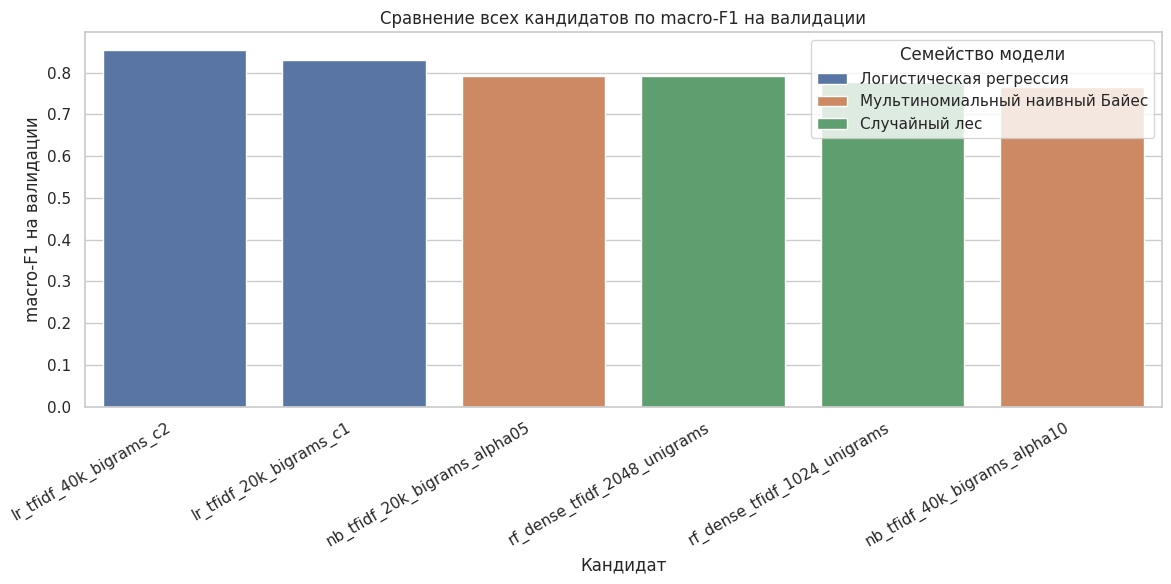

In [25]:
plt.figure(figsize=(12, 6))
chart_df = training_log_df.sort_values("val_f1_macro", ascending=False).copy()
sns.barplot(data=chart_df, x="candidate_name", y="val_f1_macro", hue="family_label")
plt.title("Сравнение всех кандидатов по macro-F1 на валидации")
plt.xlabel("Кандидат")
plt.ylabel("macro-F1 на валидации")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Семейство модели")
plt.tight_layout()
plt.show()


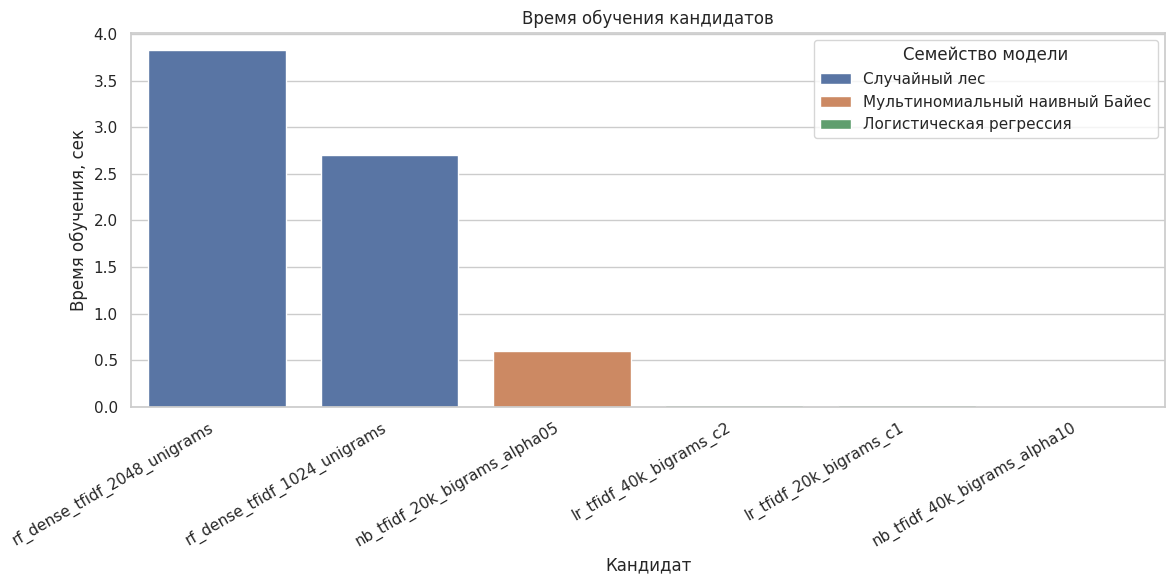

In [26]:
plt.figure(figsize=(12, 6))
chart_df = training_log_df.sort_values("fit_sec", ascending=False).copy()
sns.barplot(data=chart_df, x="candidate_name", y="fit_sec", hue="family_label")
plt.title("Время обучения кандидатов")
plt.xlabel("Кандидат")
plt.ylabel("Время обучения, сек")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Семейство модели")
plt.tight_layout()
plt.show()

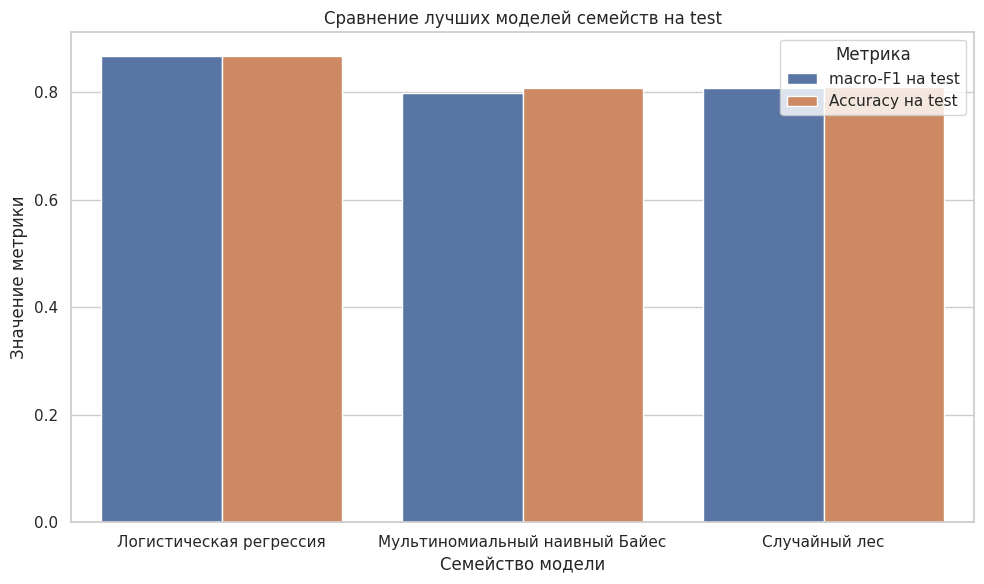

In [27]:
comparison_plot_df = best_family_df.melt(
    id_vars=["family_label", "candidate_name"],
    value_vars=["test_macro_f1", "test_accuracy"],
    var_name="metric",
    value_name="value",
)
comparison_plot_df["metric"] = comparison_plot_df["metric"].map(
    {"test_macro_f1": "macro-F1 на test", "test_accuracy": "Accuracy на test"}
)

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_plot_df, x="family_label", y="value", hue="metric")
plt.title("Сравнение лучших моделей семейств на test")
plt.xlabel("Семейство модели")
plt.ylabel("Значение метрики")
plt.legend(title="Метрика")
plt.tight_layout()
plt.show()

In [28]:
candidate_pool = []
for result in [lr_result, nb_result, rf_result]:
    candidate_pool.extend(result["candidate_results"])

best_overall = sorted(
    candidate_pool,
    key=lambda item: (item["metrics"]["val"]["f1_macro"], item["metrics"]["val"]["accuracy"]),
    reverse=True,
)[0]

display(Markdown("### Итог выбора лучшей baseline-модели"))
display(
    Markdown(
        f"""
        Лучшей итоговой конфигурацией по `val macro-F1` стала модель **{best_overall['family_label']}**
        с кандидатом **`{best_overall['candidate_name']}`**.

        - `val macro-F1`: **{best_overall['metrics']['val']['f1_macro']:.4f}**
        - `test macro-F1`: **{best_overall['metrics']['test']['f1_macro']:.4f}**
        - `test accuracy`: **{best_overall['metrics']['test']['accuracy']:.4f}**
        - время обучения: **{best_overall['fit_sec']:.4f} сек**
        - число признаков: **{best_overall['feature_count']}**
        - представление: **{best_overall['representation']}**

        `test` здесь используется только как финальная оценка уже выбранной по `val` модели.
        """
    )
)

russian_best_family_table(best_family_df)


### Итог выбора лучшей baseline-модели


        Лучшей итоговой конфигурацией по `val macro-F1` стала модель **Логистическая регрессия**
        с кандидатом **`lr_tfidf_40k_bigrams_c2`**.

        - `val macro-F1`: **0.8534**
        - `test macro-F1`: **0.8676**
        - `test accuracy`: **0.8675**
        - время обучения: **0.0193 сек**
        - число признаков: **8915**
        - представление: **разреженное**

        `test` здесь используется только как финальная оценка уже выбранной по `val` модели.
        

,Семейство модели,Лучший кандидат,Val macro-F1,Test macro-F1,Test accuracy,"Время обучения, сек",Представление
0,Логистическая регрессия,lr_tfidf_40k_bigrams_c2,0.85345,0.86763,0.86749,0.01934,разреженное
1,Мультиномиальный наивный Байес,nb_tfidf_20k_bigrams_alpha05,0.79197,0.79780,0.80708,0.60198,разреженное
2,Случайный лес,rf_dense_tfidf_2048_unigrams,0.79105,0.80750,0.80903,3.82475,плотное


### Контрольный тест по `val_f1_macro`

Ниже дополнительно фиксируется и проверяется валидационная метрика лучшей классической модели. Это позволяет явно сохранить `val_f1_macro` для дальнейшего сравнения с нейросетевыми моделями в ноутбуке `03`.

In [29]:
best_overall_log_row = (
    training_log_df.loc[training_log_df["candidate_name"] == best_overall["candidate_name"]]
    .sort_values(["val_f1_macro", "val_accuracy"], ascending=[False, False])
    .iloc[0]
)

assert "val_f1_macro" in training_log_df.columns, "В training_log_df отсутствует колонка val_f1_macro."
assert np.isclose(
    best_overall_log_row["val_f1_macro"],
    best_overall["metrics"]["val"]["f1_macro"],
), "val_f1_macro в training_log_df не совпадает с итоговой метрикой best_overall."
assert best_overall["metrics"]["val"]["f1_macro"] > 0.0, "val_f1_macro должен быть положительным."

best_classic_summary_df = pd.DataFrame(
    [
        {
            "family_label": best_overall["family_label"],
            "candidate": best_overall["candidate_name"],
            "val_f1_macro": round(best_overall["metrics"]["val"]["f1_macro"], 5),
            "val_accuracy": round(best_overall["metrics"]["val"]["accuracy"], 5),
            "test_f1_macro": round(best_overall["metrics"]["test"]["f1_macro"], 5),
            "test_accuracy": round(best_overall["metrics"]["test"]["accuracy"], 5),
            "fit_sec": round(best_overall["fit_sec"], 5),
            "feature_count": int(best_overall["feature_count"]),
            "representation": best_overall["representation"],
            "selected_by": "val_f1_macro",
        }
    ]
)

display(Markdown("### Проверка итоговой валидационной метрики"))
display(best_classic_summary_df)


### Проверка итоговой валидационной метрики

,family_label,candidate,val_f1_macro,val_accuracy,test_f1_macro,test_accuracy,fit_sec,feature_count,representation,selected_by
0,Логистическая регрессия,lr_tfidf_40k_bigrams_c2,0.85345,0.85943,0.86763,0.86749,0.01934,8915,разреженное,val_f1_macro


## Анализ ошибок лучшей модели

После выбора лучшего baseline важно понять не только общие метрики,
но и то, на каких классах модель работает особенно хорошо или особенно плохо,
а также какие типы ошибок встречаются чаще всего.

In [30]:
best_predictions_df = build_predictions_frame(split_frames["test"], best_overall["test_pred"], label_names)
best_per_class_df = per_class_metrics_frame(
    split_frames["test"]["label"].to_numpy(dtype=np.int32),
    best_overall["test_pred"],
    label_names,
)

display(Markdown("### Метрики по классам для лучшей модели"))
russian_per_class_table(best_per_class_df.head(15))


### Метрики по классам для лучшей модели

,Индекс класса,Класс,Precision,Recall,F1,Число примеров
0,5,balance_not_updated_after_bank_transfer,0.659091,0.725,0.690476,40
1,48,pending_transfer,0.827586,0.600,0.695652,40
2,14,card_not_working,0.611111,0.825,0.702128,40
3,72,virtual_card_not_working,1.000000,0.600,0.750000,40
4,66,transfer_not_received_by_recipient,0.727273,0.800,0.761905,40
5,76,wrong_exchange_rate_for_cash_withdrawal,0.848485,0.700,0.767123,40
6,16,card_payment_not_recognised,0.789474,0.750,0.769231,40
7,69,verify_my_identity,0.733333,0.825,0.776471,40
8,10,card_acceptance,0.875000,0.700,0.777778,40
9,34,extra_charge_on_statement,0.723404,0.850,0.781609,40


In [31]:
weakest_classes_df = best_per_class_df.sort_values(["f1", "support"], ascending=[True, False]).head(15)
strongest_classes_df = best_per_class_df.sort_values(["f1", "support"], ascending=[False, False]).head(15)

display(Markdown("### Слабые классы лучшей модели"))
display(russian_per_class_table(weakest_classes_df))

display(Markdown("### Сильные классы лучшей модели"))
russian_per_class_table(strongest_classes_df)


### Слабые классы лучшей модели

,Индекс класса,Класс,Precision,Recall,F1,Число примеров
0,5,balance_not_updated_after_bank_transfer,0.659091,0.725,0.690476,40
1,48,pending_transfer,0.827586,0.600,0.695652,40
2,14,card_not_working,0.611111,0.825,0.702128,40
3,72,virtual_card_not_working,1.000000,0.600,0.750000,40
4,66,transfer_not_received_by_recipient,0.727273,0.800,0.761905,40
5,76,wrong_exchange_rate_for_cash_withdrawal,0.848485,0.700,0.767123,40
6,16,card_payment_not_recognised,0.789474,0.750,0.769231,40
7,69,verify_my_identity,0.733333,0.825,0.776471,40
8,10,card_acceptance,0.875000,0.700,0.777778,40
9,34,extra_charge_on_statement,0.723404,0.850,0.781609,40


### Сильные классы лучшей модели

,Индекс класса,Класс,Precision,Recall,F1,Число примеров
74,1,age_limit,1.000000,1.000,1.000000,40
75,44,passcode_forgotten,1.000000,1.000,1.000000,40
76,71,verify_top_up,1.000000,1.000,1.000000,40
72,2,apple_pay_or_google_pay,0.975610,1.000,0.987654,40
73,30,edit_personal_details,0.975610,1.000,0.987654,40
71,42,lost_or_stolen_phone,1.000000,0.975,0.987342,40
70,70,verify_source_of_funds,0.952381,1.000,0.975610,40
69,13,card_linking,0.951220,0.975,0.962963,40
66,21,change_pin,1.000000,0.925,0.961039,40
67,46,pending_cash_withdrawal,1.000000,0.925,0.961039,40


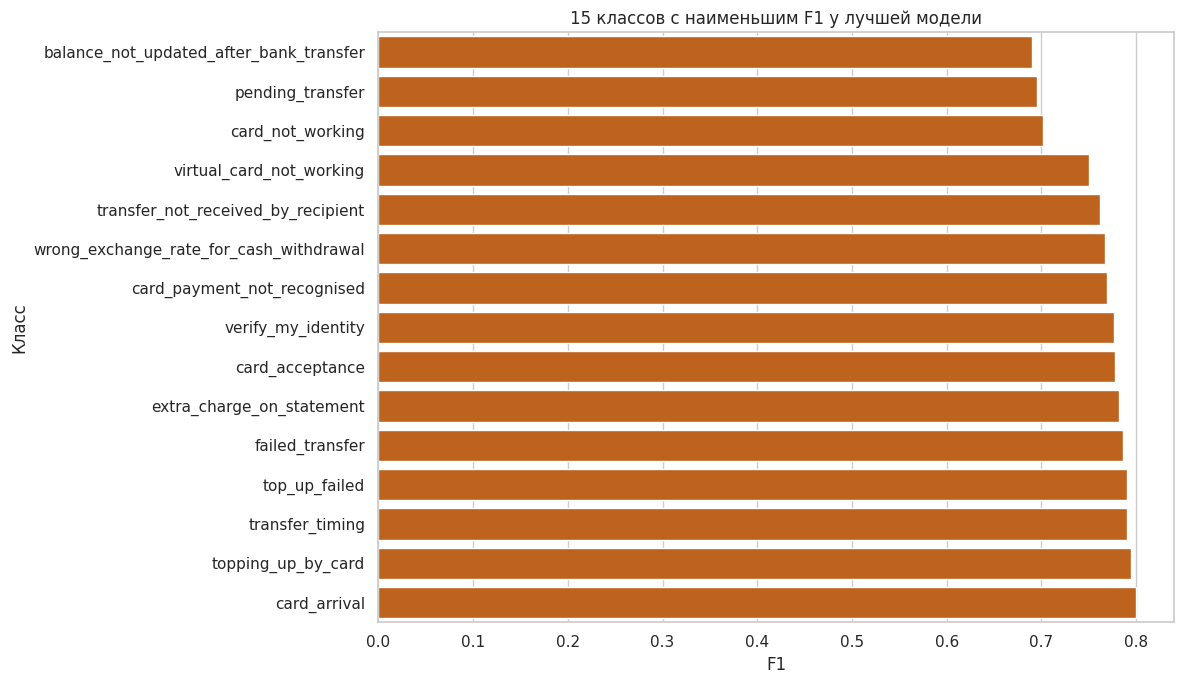

In [32]:
plt.figure(figsize=(12, 7))
plot_df = weakest_classes_df.sort_values("f1", ascending=True)
sns.barplot(data=plot_df, y="label_name", x="f1", color="#D95F02")
plt.title("15 классов с наименьшим F1 у лучшей модели")
plt.xlabel("F1")
plt.ylabel("Класс")
plt.tight_layout()
plt.show()

In [33]:
confusion_pairs_df = most_confused_pairs(best_predictions_df, top_n=15)
display(Markdown("### Наиболее частые пары ошибок"))
russian_confusion_pairs_table(confusion_pairs_df)


### Наиболее частые пары ошибок

,Истинный класс,Предсказанный класс,Количество ошибок
0,virtual_card_not_working,getting_virtual_card,8
1,card_acceptance,card_not_working,7
2,unable_to_verify_identity,verify_my_identity,6
3,pin_blocked,get_physical_card,5
4,top_up_reverted,top_up_failed,5
5,why_verify_identity,verify_my_identity,5
6,request_refund,Refund_not_showing_up,5
7,pending_transfer,transfer_timing,5
8,top_up_by_cash_or_cheque,balance_not_updated_after_cheque_or_cash_deposit,4
9,wrong_exchange_rate_for_cash_withdrawal,card_payment_wrong_exchange_rate,4


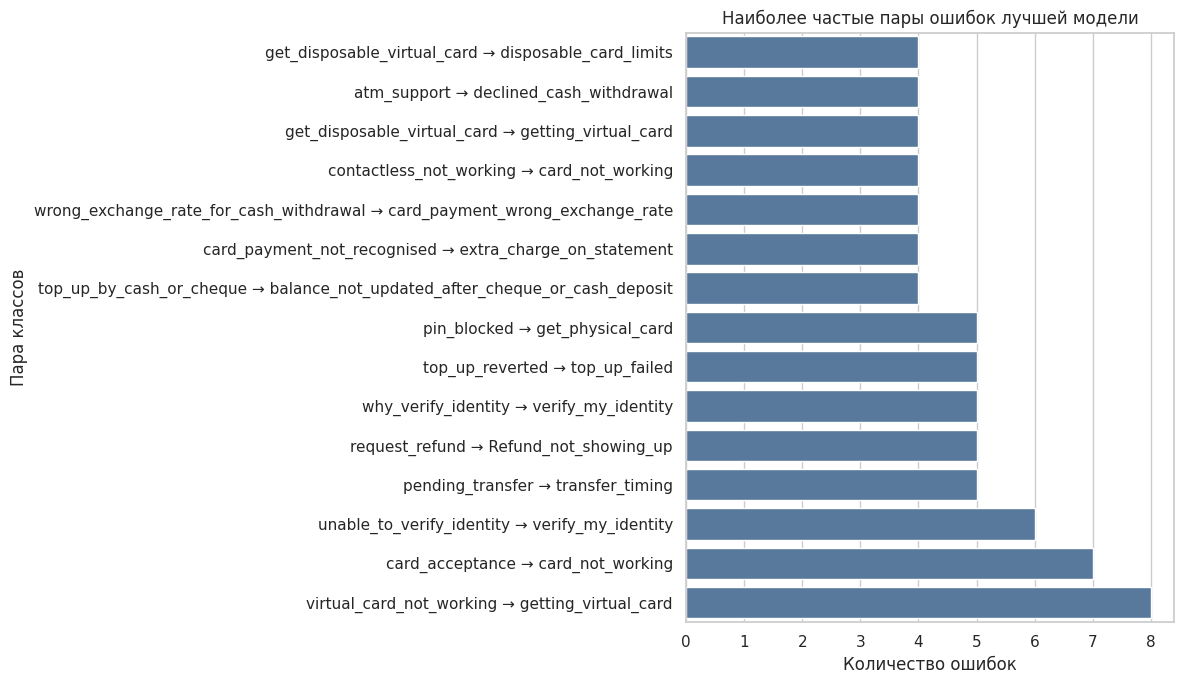

In [34]:
if not confusion_pairs_df.empty:
    plot_df = confusion_pairs_df.copy()
    plot_df["pair"] = plot_df["label_name"] + " → " + plot_df["prediction_name"]

    plt.figure(figsize=(12, 7))
    sns.barplot(data=plot_df.sort_values("count", ascending=True), y="pair", x="count", color="#4C78A8")
    plt.title("Наиболее частые пары ошибок лучшей модели")
    plt.xlabel("Количество ошибок")
    plt.ylabel("Пара классов")
    plt.tight_layout()
    plt.show()
else:
    print("Ошибок не обнаружено, график пар ошибок не строится.")

In [35]:
display(Markdown("### Примеры ошибочных предсказаний"))
error_examples_df = (
    best_predictions_df.loc[~best_predictions_df["is_correct"], ["text", "label_name", "prediction_name"]]
    .head(12)
    .reset_index(drop=True)
)
russian_error_examples_table(error_examples_df)


### Примеры ошибочных предсказаний

,Текст обращения,Истинный класс,Предсказанный класс
0,How do I locate my card?,card_arrival,card_not_working
1,I ordered a card but it has not arrived. Help please!,card_arrival,transfer_not_received_by_recipient
2,When will I get my card?,card_arrival,card_delivery_estimate
3,How long does a card delivery take?,card_arrival,card_delivery_estimate
4,How do I know when my card will arrive?,card_arrival,card_delivery_estimate
5,"I'm starting to think my card is lost because it still hasn't arrived, can you help?",card_arrival,lost_or_stolen_card
6,Can I link another card to my account?,card_linking,getting_spare_card
7,Is it a good time to exchange?,exchange_rate,exchange_via_app
8,The exchange rate would be?,exchange_rate,card_payment_wrong_exchange_rate
9,when does the rate get determined,exchange_rate,card_payment_wrong_exchange_rate


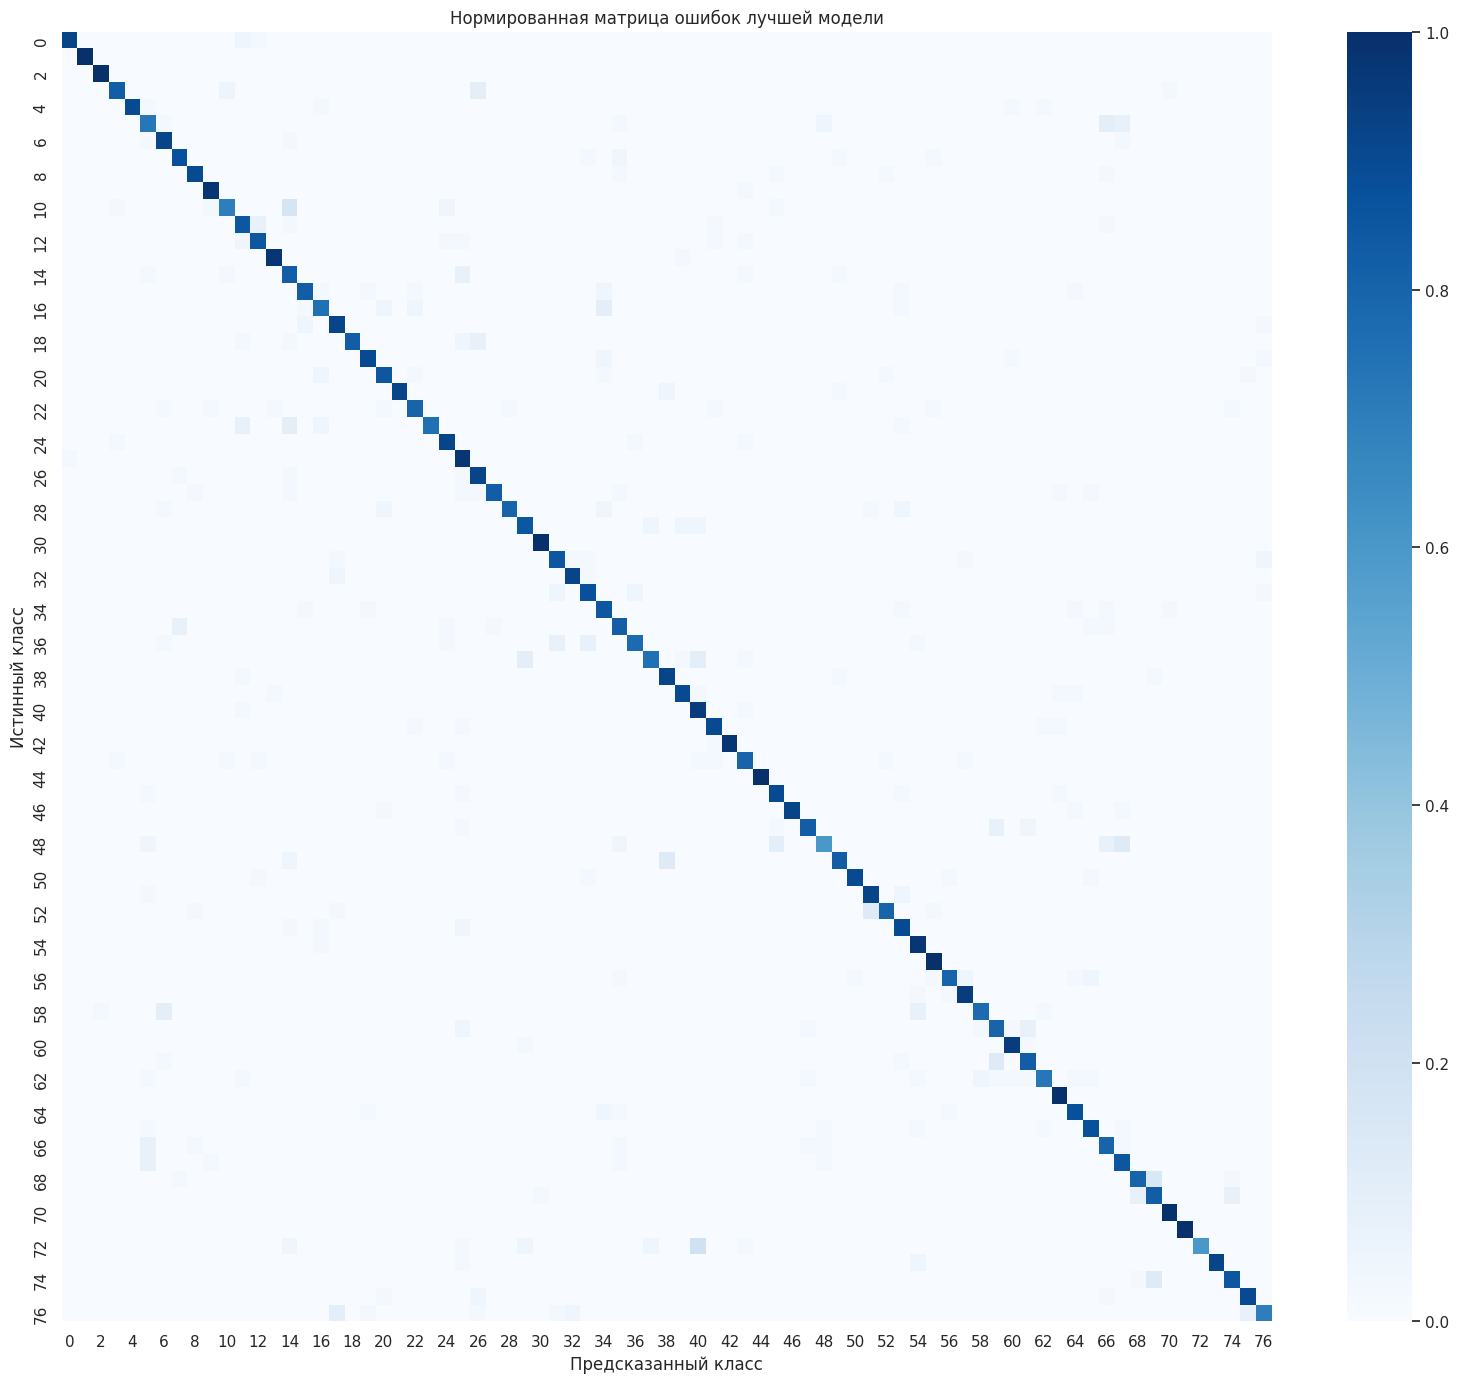

In [36]:
confusion_matrix_path = REPORTS_DIR / f"confusion_matrix_{best_overall['candidate_name']}.png"
save_confusion_matrix_figure(
    split_frames["test"]["label"].to_numpy(dtype=np.int32),
    best_overall["test_pred"],
    label_names,
    confusion_matrix_path,
)

## Сохранение артефактов

В этом блоке сохраняются итоговые таблицы и модели так, чтобы ими можно было пользоваться
дальше — в отчёте, в будущих ноутбуках и в блоке инференса/маршрутизации.

In [37]:
training_log_path = REPORTS_DIR / "training_log_detailed.csv"
training_log_df.to_csv(training_log_path, index=False)

metrics_summary_path = REPORTS_DIR / "metrics_summary.csv"
metrics_summary_df.sort_values(["split", "f1_macro", "accuracy"], ascending=[True, False, False]).to_csv(metrics_summary_path, index=False)

per_class_metrics_path = REPORTS_DIR / f"per_class_metrics_{best_overall['candidate_name']}.csv"
best_per_class_df.to_csv(per_class_metrics_path, index=False)

predictions_path = REPORTS_DIR / f"predictions_{best_overall['candidate_name']}.csv"
best_predictions_df.to_csv(predictions_path, index=False)

best_classic_summary_path = REPORTS_DIR / "best_classic_model_summary.csv"
best_classic_summary_df.to_csv(best_classic_summary_path, index=False)

family_result_map = {
    "logistic_regression": lr_result,
    "multinomial_nb": nb_result,
    "random_forest": rf_result,
}

for family_name, result in family_result_map.items():
    candidate = result["best_candidate"]
    save_pickle(
        {
            "model_name": family_name,
            "family_label": result["family_label"],
            "candidate_name": candidate["candidate_name"],
            "representation": candidate["representation"],
            "vectorizer_kwargs": candidate["vectorizer_kwargs"],
            "model_description": candidate["model_description"],
            "vectorizer": candidate["vectorizer"],
            "model": candidate["model"],
            "label_names": label_names,
            "runtime": runtime,
            "metrics": candidate["metrics"],
        },
        MODELS_DIR / f"{family_name}_bundle.pkl",
    )

artifact_paths_df = pd.DataFrame(
    {
        "Артефакт": [
            "Подробный лог обучения",
            "Сводная таблица метрик",
            "Метрики по классам лучшей модели",
            "Предсказания лучшей модели",
            "Сводка по лучшей классической модели",
            "Матрица ошибок лучшей модели",
            "Bundle Logistic Regression",
            "Bundle MultinomialNB",
            "Bundle RandomForest",
        ],
        "Путь": [
            str(training_log_path),
            str(metrics_summary_path),
            str(per_class_metrics_path),
            str(predictions_path),
            str(best_classic_summary_path),
            str(confusion_matrix_path),
            str(MODELS_DIR / 'logistic_regression_bundle.pkl'),
            str(MODELS_DIR / 'multinomial_nb_bundle.pkl'),
            str(MODELS_DIR / 'random_forest_bundle.pkl'),
        ],
    }
)
artifact_paths_df

,Артефакт,Путь
0,Подробный лог обучения,/home/sukuna/Projects/RNN/artifacts/reports/training_log_detailed.csv
1,Сводная таблица метрик,/home/sukuna/Projects/RNN/artifacts/reports/metrics_summary.csv
2,Метрики по классам лучшей модели,/home/sukuna/Projects/RNN/artifacts/reports/per_class_metrics_lr_tfidf_40k_bigrams_c2.csv
3,Предсказания лучшей модели,/home/sukuna/Projects/RNN/artifacts/reports/predictions_lr_tfidf_40k_bigrams_c2.csv
4,Сводка по лучшей классической модели,/home/sukuna/Projects/RNN/artifacts/reports/best_classic_model_summary.csv
5,Матрица ошибок лучшей модели,/home/sukuna/Projects/RNN/artifacts/reports/confusion_matrix_lr_tfidf_40k_bigrams_c2.png
6,Bundle Logistic Regression,/home/sukuna/Projects/RNN/artifacts/models/logistic_regression_bundle.pkl
7,Bundle MultinomialNB,/home/sukuna/Projects/RNN/artifacts/models/multinomial_nb_bundle.pkl
8,Bundle RandomForest,/home/sukuna/Projects/RNN/artifacts/models/random_forest_bundle.pkl
